# VL-BERT: Pre-Training of Generic Visual-Linguistic Representations

# https://arxiv.org/pdf/1908.08530

**Authors:** Weijie Su, Xizhou Zhu, Yue Cao, Bin Li, Lewei Lu, Furu Wei, Jifeng Dai
**Affiliations:** University of Science and Technology of China, Microsoft Research Asia
**Venue:** ICLR 2020

---

## Abstract

VL-BERT is a pre-trainable generic representation framework for visual-linguistic
tasks. It extends the Transformer architecture to jointly process both visual
region-of-interest (RoI) features and linguistic word tokens as input elements
within a single unified model. Pre-trained on the large-scale Conceptual Captions
dataset together with text-only corpora (BooksCorpus and English Wikipedia),
VL-BERT achieves state-of-the-art results on Visual Commonsense Reasoning (VCR),
Visual Question Answering (VQA), and Referring Expression Comprehension
(RefCOCO+), with a first-place single-model ranking on the VCR leaderboard.

---

## Problems

1. **Absence of generic visual-linguistic pre-training** — No universal pre-trained
   backbone existed for vision-language tasks, unlike ImageNet pre-training for
   vision or BERT pre-training for language. All prior models were task-specific
   and trained from scratch on small target datasets.

2. **Task-specific, ad-hoc model designs** — Previous approaches combined separately
   pre-trained vision and NLP backbones in task-specific fusion modules, making it
   difficult to generalize across tasks and prone to overfitting on scarce data.

3. **Restricted cross-modal attention in two-stream architectures** — Concurrent models
   such as ViLBERT and LXMERT use two separate single-modal Transformers with a
   restricted cross-modal Transformer layer, limiting the depth and freedom of
   visual-linguistic interaction.

4. **Visual clue leakage in masked RoI pre-training** — Prior masked visual prediction
   tasks masked features at the feature-map level, allowing residual visual information
   to leak through convolutional layers and weakening the pre-training signal.

5. **Overfitting to short and simple sentences** — Pre-training on captioning datasets
   alone produces representations poorly suited to downstream tasks involving long
   and complex sentences (e.g., VCR rationales averaging 33.7 words per sample).

6. **Harmful effect of Sentence-Image Relationship Prediction** — The sentence-image
   alignment pre-training task used by all concurrent works introduces unmatched
   image-caption pairs as negatives, which empirically hurts performance on all
   downstream tasks when incorporated.

---

## Proposed Solutions

1. **Single unified Transformer architecture** — A single multi-layer bidirectional
   Transformer processes both visual and linguistic elements jointly, enabling
   unrestricted, all-layer, all-pair self-attention between words and image RoIs.

2. **Four-component input embedding** — Each input element's embedding is the sum
   of four components: token embedding, visual feature embedding, segment embedding,
   and sequence position embedding.

3. **Visual feature embedding** — A new embedding type combining:
   - Visual appearance features from Fast R-CNN (2048-d RoI features)
   - Visual geometry embedding encoding normalized bounding-box coordinates via
     sinusoidal functions

4. **Two pre-training tasks** (without Sentence-Image Relationship Prediction):
   - Task 1: Masked Language Modeling with Visual Clues
   - Task 2: Masked RoI Classification with Linguistic Clues

5. **Pixel-level masking for RoI pre-training** — Masked RoI pixels are zeroed out
   in the raw input image before applying Fast R-CNN, preventing visual clue leakage
   through convolutional layers.

6. **Joint pre-training on visual-linguistic and text-only corpora** — Conceptual
   Captions (3.3M image-caption pairs) combined with BooksCorpus and English Wikipedia
   (1:1 sampling ratio) addresses overfitting to short captions.

7. **End-to-end training of Fast R-CNN parameters** — Visual feature parameters are
   jointly updated with the Transformer during both pre-training and fine-tuning,
   unlike prior works that freeze the visual backbone.

---

## Purpose

To develop a single universal pre-trained backbone for visual-linguistic tasks that:

1. Learns rich joint representations of image regions and language through
   unrestricted self-attention across all modalities and all layers.
2. Eliminates the need for ad-hoc task-specific fusion modules.
3. Transfers effectively to diverse downstream tasks through minimal fine-tuning
   of input format, output head, and loss function.
4. Improves over two-stream architectures by allowing free and deep cross-modal
   interaction from the first layer onward.

---

## Methodology

### 3.1 Transformer Backbone (BERT Revisit)

VL-BERT builds directly on the BERT Transformer. At each layer $\ell$, the
feature update equations are:

**Multi-head Attention:**

$$\tilde{h}_i^{\ell+1} = \sum_{m=1}^{M} W_m^{\ell+1}
\left\{ \sum_{j=1}^{N} A_{i,j}^m \cdot V_m^{\ell+1} x_j^\ell \right\}$$

where attention weights satisfy:

$$A_{i,j}^m \propto \exp\!\left[(Q_m^{\ell+1} x_i^\ell)^\top
(K_m^{\ell+1} x_j^\ell)\right], \quad
\sum_{j=1}^{N} A_{i,j}^m = 1$$

**Residual Connection + LayerNorm:**

$$h_i^{\ell+1} = \text{LayerNorm}(x_i^\ell + \tilde{h}_i^{\ell+1})$$

**Feed-Forward Sublayer:**

$$\tilde{x}_i^{\ell+1} = W_2^{\ell+1} \cdot
\text{GELU}(W_1^{\ell+1} h_i^{\ell+1} + b_1^{\ell+1}) + b_2^{\ell+1}$$

**Second Residual Connection + LayerNorm:**

$$x_i^{\ell+1} = \text{LayerNorm}(h_i^{\ell+1} + \tilde{x}_i^{\ell+1})$$

---

### 3.2 Input Embedding Design

Each input element's embedding is the sum of four components:

$$e_i = e_{\text{token}} + e_{\text{visual}} + e_{\text{segment}} + e_{\text{position}}$$

**Visual Geometry Embedding** — Each RoI is characterized by a normalized 4-d
bounding-box vector:

$$g = \left(\frac{x_{\text{LT}}}{W},\ \frac{y_{\text{LT}}}{H},\
\frac{x_{\text{RB}}}{W},\ \frac{y_{\text{RB}}}{H}\right)$$

This 4-d vector is projected to 2048-d via sinusoidal functions of different
wavelengths (following Relation Networks).

**Visual Feature Embedding** — The final visual feature embedding is:

$$e_{\text{visual}} = \text{FC}([\text{AppearanceFeature};\
\text{GeometryEmbedding}])$$

where $[\cdot;\cdot]$ denotes concatenation and FC is a fully connected layer.

**Segment Embedding** — Three segment types are defined:
- Segment $A$: words from the first input sentence
- Segment $B$: words from the second input sentence
- Segment $C$: all RoIs from the input image

---

### 3.3 Pre-Training Tasks

**Task 1 — Masked Language Modeling with Visual Clues:**

Each word is masked with probability $p = 0.15$. The model predicts the masked
word from unmasked words and all visual features:

$$\mathcal{L}_{\text{MLM}}(\theta) = -\mathbb{E}_{x \sim \mathcal{D},\
i \sim \{1,\ldots,N\}} \log \phi_i(x|\theta)$$

where the log-potential is:

$$\log \phi_i(x|\theta) = x_i^\top f_i(x_{\backslash i}|\theta)$$

**Task 2 — Masked RoI Classification with Linguistic Clues:**

Each RoI is masked with probability $p = 0.15$ by zeroing its pixels in the
raw image before Fast R-CNN. The model predicts the object category from
unmasked visual and all linguistic features:

$$\mathcal{L}_{\text{RoI}}(\theta) = -\mathbb{E}
\left[\log P(\hat{c}_j \mid x_{\backslash j},\ \text{linguistic clues})\right]$$

**Combined Pre-Training Loss:**

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{RoI}}$$

**Note:** The Sentence-Image Relationship Prediction task is explicitly excluded
after ablation confirms it hurts all downstream tasks.

---

### 3.4 Fine-Tuning Protocol

| Task | Input Format | Output Head |
|---|---|---|
| VCR (Q→A, QA→R) | \<Question, Answer, Image\> | Softmax on [CLS] |
| VQA | \<Question, [MASK], Image\> | Multi-class classifier on [MASK] |
| RefCOCO+ | \<Query, Image\> | Binary classifier on each [IMG] token |

---

### 3.5 Training Configuration

| Parameter | Value |
|---|---|
| Pre-training hardware | 16 Tesla V100 GPUs |
| Pre-training iterations | 250,000 steps |
| Batch size | 256 (128 image-caption + 128 text-only) |
| Optimizer | Adam |
| Base learning rate | $2 \times 10^{-5}$ |
| Adam $\beta_1$, $\beta_2$ | 0.9, 0.999 |
| Weight decay | $10^{-4}$ |
| Warm-up steps | 8,000 |
| Learning rate decay | Linear |
| Max RoIs per image | 100 (score $\geq 0.5$, min 10) |
| Parameter initialization | BERT$_{\text{BASE}}$ / BERT$_{\text{LARGE}}$ |

---

## Results

### Visual Commonsense Reasoning (VCR)

| Model | Q→A Val | QA→R Val | Q→AR Val | Q→AR Test |
|---|---|---|---|---|
| R2C (Zellers et al., 2019) | 63.8 | 67.2 | 43.1 | 44.0 |
| ViLBERT | 72.4 | 74.5 | 54.0 | 54.8 |
| VisualBERT | 70.8 | 73.2 | 52.2 | 52.4 |
| B2T2 | 71.9 | 76.0 | 54.9 | 55.0 |
| VL-BERT$_{\text{BASE}}$ w/o pre-training | 73.1 | 73.8 | 54.2 | — |
| VL-BERT$_{\text{BASE}}$ | 73.8 | 74.4 | 55.2 | — |
| **VL-BERT$_{\text{LARGE}}$** | **75.5** | **77.9** | **58.9** | **59.7** |

### Visual Question Answering (VQA v2.0)

| Model | Test-Dev | Test-Std |
|---|---|---|
| BUTD | 65.32 | 65.67 |
| ViLBERT | 70.55 | 70.92 |
| VisualBERT | 70.80 | 71.00 |
| LXMERT | 72.42 | 72.54 |
| VL-BERT$_{\text{BASE}}$ w/o pre-training | 69.58 | — |
| VL-BERT$_{\text{BASE}}$ | 71.16 | — |
| **VL-BERT$_{\text{LARGE}}$** | **71.79** | **72.22** |

### Referring Expression Comprehension (RefCOCO+)

| Model | GT Val | GT testA | GT testB | Det Val | Det testA | Det testB |
|---|---|---|---|---|---|---|
| MAttNet | 71.01 | 75.13 | 66.17 | 65.33 | 71.62 | 56.02 |
| ViLBERT | — | — | — | 72.34 | 78.52 | 62.61 |
| VL-BERT$_{\text{BASE}}$ w/o pre-training | 74.41 | 77.28 | 67.52 | 66.03 | 71.87 | 56.13 |
| VL-BERT$_{\text{BASE}}$ | 79.88 | 82.40 | 75.01 | 71.60 | 77.72 | 60.99 |
| **VL-BERT$_{\text{LARGE}}$** | **80.31** | **83.62** | **75.45** | **72.59** | **78.57** | **62.30** |

### Ablation Study (VL-BERT$_{\text{BASE}}$, 0.5x fine-tuning epochs)

| Setting | VCR Q→A | VCR QA→R | VQA Test-Dev | RefCOCO+ Det Val |
|---|---|---|---|---|
| w/o pre-training | 72.9 | 73.0 | 69.5 | 62.7 |
| (a) MLM only | 72.9 | 73.1 | 71.0 | 69.1 |
| (b) MLM + RoI Cls | 73.0 | 73.1 | 71.1 | 70.7 |
| (c) MLM + RoI Cls + Sent-Img | 72.2 | 72.4 | 70.3 | 69.5 |
| (d) MLM + RoI Cls + Text-Only | 73.4 | 73.8 | 71.1 | 70.7 |
| VL-BERT$_{\text{BASE}}$ (all) | **73.8** | **73.9** | **71.2** | **71.1** |

Key ablation findings:
- Adding Sentence-Image Relationship Prediction **(c)** consistently **hurts**
  all downstream tasks, confirming its exclusion from VL-BERT
- Text-only corpus joint training **(d)** provides the largest single gain on
  VCR (+1.2%) due to longer, more complex sentences in that task
- End-to-end Fast R-CNN fine-tuning provides consistent improvement across all tasks

---

## Conclusions

VL-BERT demonstrates that a single unified Transformer model, pre-trained jointly
on visual-linguistic and text-only corpora with carefully selected pre-training
tasks, constitutes a strong generic backbone for diverse vision-language tasks.
Three design decisions differentiate VL-BERT from all concurrent works: (1)
exclusion of the harmful Sentence-Image Relationship Prediction task; (2) joint
pre-training on text-only corpora to improve generalization over long and complex
sentences; and (3) pixel-level masking and end-to-end Fast R-CNN fine-tuning to
avoid visual clue leakage and improve visual feature quality. VL-BERT achieves
first place on the VCR single-model leaderboard and state-of-the-art results on
VQA and RefCOCO+, validating the effectiveness of the unified single-stream
architecture over two-stream designs for generic visual-linguistic representation
learning.


# VL-BERT: Mathematical and Statistical Content Summary

---

## 1. Transformer Layer Computations

The entire VL-BERT model is built on stacked Transformer layers.
Each layer $\ell$ transforms input features $x^\ell = \{x_1^\ell, \ldots, x_N^\ell\}$
into output features $x^{\ell+1}$ through four sequential operations:

---

### 1.1 Multi-Head Self-Attention

The core operation allowing every input element — whether a word token or an
image RoI — to gather information from every other element:

$$\tilde{h}_i^{\ell+1} = \sum_{m=1}^{M} W_m^{\ell+1}
\left\{ \sum_{j=1}^{N} A_{i,j}^m \cdot V_m^{\ell+1} x_j^\ell \right\}$$

where:
- $M$ is the number of attention heads
- $N$ is the total number of input elements (words + RoIs)
- $W_m^{\ell+1}$, $V_m^{\ell+1}$ are learnable projection matrices for head $m$
- $A_{i,j}^m$ is the attention weight from element $i$ to element $j$ in head $m$

The attention weight is computed as a normalized dot-product score:

$$A_{i,j}^m \propto \exp\!\left[
\left(Q_m^{\ell+1} x_i^\ell\right)^\top
\left(K_m^{\ell+1} x_j^\ell\right)
\right]$$

with the normalization constraint:

$$\sum_{j=1}^{N} A_{i,j}^m = 1 \quad \forall\ i, m$$

**Role:** This is the mechanism that implicitly aligns and aggregates information
across vision and language. Since all visual and linguistic tokens are treated
as elements in the same sequence, every word can attend to every image region
and vice versa — with no architectural restriction on which pairs interact.

**Key property noted in the paper:** The Transformer attention is
*order-invariant* — permuting the input sequence produces the same output
after the same permutation. Position information is therefore encoded
entirely through position embeddings, not sequence order.

---

### 1.2 First Residual Connection and Layer Normalization

$$h_i^{\ell+1} = \text{LayerNorm}\!\left(x_i^\ell + \tilde{h}_i^{\ell+1}\right)$$

**Role:** The residual connection $x_i^\ell + \tilde{h}_i^{\ell+1}$ prevents
vanishing gradients in deep networks by providing a shortcut path for gradient
flow. LayerNorm stabilizes the scale of activations across the feature dimension.

---

### 1.3 Feed-Forward Sublayer

Each element's representation is further transformed by a two-layer
fully-connected network with GELU activation:

$$\tilde{x}_i^{\ell+1} = W_2^{\ell+1} \cdot
\text{GELU}\!\left(W_1^{\ell+1} h_i^{\ell+1} + b_1^{\ell+1}\right) + b_2^{\ell+1}$$

where the GELU (Gaussian Error Linear Unit) activation is:

$$\text{GELU}(z) = z \cdot \Phi(z) \approx
0.5z\!\left(1 + \tanh\!\left[\sqrt{\frac{2}{\pi}}
\left(z + 0.044715z^3\right)\right]\right)$$

and $\Phi(z)$ is the standard Gaussian cumulative distribution function.

**Role:** Introduces non-linearity and per-element transformation after the
attention-based aggregation step.

---

### 1.4 Second Residual Connection and Layer Normalization

$$x_i^{\ell+1} = \text{LayerNorm}\!\left(h_i^{\ell+1} + \tilde{x}_i^{\ell+1}\right)$$

**Role:** Same stabilization purpose as the first residual connection,
applied after the feed-forward sublayer.

---

## 2. Input Embedding Formulation

Each input element's embedding is the element-wise sum of four components:

$$e_i = e_{\text{token}} + e_{\text{visual}} + e_{\text{segment}} + e_{\text{position}}$$

**Role:** Encodes four orthogonal sources of information — word identity,
visual appearance and geometry, modality/sentence membership, and
sequence position — into a single unified representation vector.

---

### 2.1 Visual Geometry Embedding

Each image region (RoI) is spatially characterized by a normalized 4-dimensional
bounding-box coordinate vector:

$$g = \left(
\frac{x_{\text{LT}}}{W},\quad
\frac{y_{\text{LT}}}{H},\quad
\frac{x_{\text{RB}}}{W},\quad
\frac{y_{\text{RB}}}{H}
\right) \in [0,1]^4$$

where:
- $(x_{\text{LT}}, y_{\text{LT}})$ are the top-left corner coordinates
- $(x_{\text{RB}}, y_{\text{RB}})$ are the bottom-right corner coordinates
- $W$, $H$ are the image width and height

This 4-d vector is then projected to a 2048-dimensional representation
using sinusoidal functions of different wavelengths (following Relation Networks):

$$e_{\text{geometry}} = [\sin(\omega_1 g_k),\ \cos(\omega_1 g_k),\
\sin(\omega_2 g_k),\ \cos(\omega_2 g_k),\ \ldots]$$

**Role:** Encodes the spatial location of each visual region into a
high-dimensional continuous space, enabling the model to reason about
relative positions and spatial relationships between objects.

---

### 2.2 Visual Feature Embedding

The final visual feature embedding for each RoI is computed by a fully-connected
projection of the concatenated appearance and geometry features:

$$e_{\text{visual}} = \text{FC}\!\left(
\left[f_{\text{appearance}}\ ;\ e_{\text{geometry}}\right]
\right)$$

where:
- $f_{\text{appearance}} \in \mathbb{R}^{2048}$ is the Fast R-CNN RoI feature
- $e_{\text{geometry}} \in \mathbb{R}^{2048}$ is the sinusoidal geometry embedding
- $[\cdot\ ;\ \cdot]$ denotes vector concatenation
- $\text{FC}$ projects the 4096-d concatenation to $d_{\text{model}}$

**Role:** Combines "what the region looks like" (appearance) with
"where the region is" (geometry) into a single visual token that can
be processed on equal footing with word tokens.

---

## 3. Pre-Training Objectives

### 3.1 Masked Language Model (MLM) as a Markov Random Field

Following Wang and Cho (2019), the paper interprets MLM pre-training as
optimizing a joint probability distribution over the input sequence.
The overall objective is:

$$\log P(x|\theta) = \frac{1}{Z(\theta)} \sum_{i=1}^{N} \log \phi_i(x|\theta)$$

where:
- $\theta$ denotes all model parameters
- $Z(\theta)$ is the partition function (normalization constant)
- $\phi_i(x|\theta)$ is the potential function for the $i$-th element

Each log-potential is defined as the dot product between the true token
representation and the model's predicted output feature:

$$\log \phi_i(x|\theta) = x_i^\top f_i(x_{\backslash i}|\theta)$$

where $f_i(x_{\backslash i}|\theta)$ is the final output feature of the model
at position $i$ when the input has position $i$ masked:

$$x_{\backslash i} = \{x_1, \ldots, x_{i-1},\ [\text{MASK}],\
x_{i+1}, \ldots, x_N\}$$

**Role:** Provides a principled probabilistic interpretation of the masking
objective — the model is learning to maximize the likelihood of each token
given the rest of the sequence (including visual context in VL-BERT).

---

### 3.2 Masked Language Modeling Loss (Task 1)

The operational training loss for Task 1 is the expected negative log-potential
over randomly sampled sentences and masking positions:

$$\mathcal{L}_{\text{MLM}}(\theta) = -\mathbb{E}_{x \sim \mathcal{D},\
i \sim \{1,\ldots,N\}} \log \phi_i(x|\theta)$$

In practice, this is implemented as Softmax cross-entropy over the full
vocabulary $\mathcal{V}$ for each masked position:

$$\mathcal{L}_{\text{MLM}} = -\sum_{i \in \mathcal{M}}
\log \frac{\exp(W_v f_i(x_{\backslash i}|\theta))}
{\sum_{v' \in \mathcal{V}} \exp(W_{v'} f_i(x_{\backslash i}|\theta))}$$

where $\mathcal{M}$ is the set of masked token positions (each word masked
independently with probability $p = 0.15$).

**Role:** Drives the model to learn both intra-linguistic dependencies
and cross-modal visual-linguistic alignment simultaneously, since the visual
context is always available for predicting masked words.

---

### 3.3 Masked RoI Classification Loss (Task 2)

Each RoI is independently masked with probability $p = 0.15$.
The model predicts the object category $c_j$ of each masked RoI $j$
from all linguistic tokens and all remaining visible RoIs:

$$\mathcal{L}_{\text{RoI}}(\theta) = -\mathbb{E}
\left[\sum_{j \in \mathcal{M}_v}
\log P\!\left(c_j \mid x_{\backslash j},\
\text{linguistic tokens}\right)\right]$$

implemented as Softmax cross-entropy over object categories, where
category labels are provided by the pre-trained Faster R-CNN detector.

**Critical design choice:** The masking is applied to the **raw input pixels**
(set to zero in the image before Fast R-CNN), not to the extracted feature maps.
This prevents visual clue leakage through convolutional layers:

$$I_{\text{masked}}(p) = \begin{cases}
0 & \text{if pixel } p \in \text{masked RoI} \\
I(p) & \text{otherwise}
\end{cases}$$

**Role:** Trains the model to infer visual object categories from linguistic
context alone, complementary to Task 1 which infers words from visual context.
Together they drive bidirectional cross-modal alignment.

---

### 3.4 Combined Pre-Training Loss

Both tasks are optimized simultaneously with equal weighting:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{RoI}}$$

For text-only samples (drawn from BooksCorpus and Wikipedia), Task 2 is
omitted and only standard MLM is applied:

$$\mathcal{L}_{\text{text-only}} = \mathcal{L}_{\text{MLM}}$$

---

### 3.5 Next Sentence Prediction Loss (BERT Reference, Excluded from VL-BERT)

For completeness, the paper defines the Next Sentence Prediction (NSP) loss
used in the original BERT (but explicitly excluded from VL-BERT pre-training):

$$\mathcal{L}_{\text{NSP}}(\theta) = -\mathbb{E}_{(x,t) \sim \mathcal{D}}
\left[t \log g(x_0^L) + (1-t)\log(1 - g(x_0^L))\right]$$

where:
- $x_0^L$ is the final-layer output feature of the $[\text{CLS}]$ element
- $g(x_0^L)$ is a sigmoid classifier output
- $t \in \{0, 1\}$ indicates whether the two sentences are consecutive

The ablation study (Table 4, setting (c)) empirically confirms that the
analogous Sentence-Image Relationship Prediction task **hurts** all downstream
tasks and is therefore excluded from VL-BERT.

---

## 4. Optimization Configuration

The Adam optimizer update rule used throughout pre-training and fine-tuning:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) \nabla_\theta \mathcal{L}$$

$$v_t = \beta_2 v_{t-1} + (1 - \beta_2)(\nabla_\theta \mathcal{L})^2$$

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad
\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

$$\theta_t = \theta_{t-1} -
\frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

| Parameter | Pre-training | VCR Fine-tuning | VQA / RefCOCO+ |
|---|---|---|---|
| Optimizer | Adam | SGD + momentum | Adam |
| Base lr $\eta$ | $2 \times 10^{-5}$ | $5 \times 10^{-3}$ | $1 \times 10^{-4}$ |
| $\beta_1$ | 0.9 | 0.9 (momentum) | 0.9 |
| $\beta_2$ | 0.999 | — | 0.999 |
| Weight decay | $10^{-4}$ | $10^{-4}$ | $10^{-4}$ |
| Warm-up steps | 8,000 | 1,000 | 500–2,000 |
| lr schedule | Linear decay | Step decay at epochs 14, 18 | Linear decay |

---

## 5. Attention Weight Normalization and Visualization

For visualization purposes (Figure 3, Appendix), the raw attention weights
$A_{i,j}^m$ are affinely rescaled per layer and per head:

$$\hat{A}_{i,j}^m = \frac{A_{i,j}^m - \min_{i',j'} A_{i',j'}^m}
{\max_{i',j'} A_{i',j'}^m - \min_{i',j'} A_{i',j'}^m}$$

so that the maximum rescaled weight equals 1 and the minimum equals 0
within each attention head at each layer.

**Role:** Normalizes attention magnitudes across heads and layers to make
cross-modal alignment patterns visually comparable.

---

## 6. Evaluation Metrics

| Task | Metric | Definition |
|---|---|---|
| VCR | Accuracy (Q→A, QA→R, Q→AR) | $\text{Acc} = \frac{\text{correct predictions}}{\text{total samples}}$ |
| VQA | Accuracy (soft) | $\min\!\left(1,\ \frac{\text{human agreement count}}{3}\right)$ per answer |
| RefCOCO+ | Accuracy (Ground-truth / Detected) | Fraction of referring expressions correctly localized |

For RefCOCO+, ground-truth region accuracy uses annotated bounding boxes,
while detected region accuracy uses Faster R-CNN proposals — making the
latter a strictly harder evaluation setting.

---

## 7. Masking Probability and Batch Composition Statistics

| Parameter | Value |
|---|---|
| Word masking probability | $p_w = 0.15$ |
| RoI masking probability | $p_r = 0.15$ |
| Max RoIs per image | 100 (score $\geq 0.5$, min 10) |
| Batch size | 256 total |
| Image-caption samples per batch | 128 |
| Text-only samples per batch | 128 |
| Sampling ratio (visual : text-only) | 1 : 1 |
| Vocabulary size (WordPiece) | 30,000 |
| Visual feature dimension | 2,048-d |
| Geometry embedding dimension | 2,048-d |

# VL-BERT: Problem — Limitation — Solution Analysis

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in VL-BERT |
|---|---|---|---|
| 1 | **No generic pre-trained backbone for vision-language tasks** — Unlike ImageNet pre-training for vision or BERT for language, no universal pre-trained representation existed for joint visual-linguistic understanding. | Every vision-language model required task-specific architecture design and training from scratch on small target datasets, causing overfitting and poor generalization across tasks. | A single unified Transformer backbone pre-trained on 3.3M Conceptual Captions image-caption pairs jointly with BooksCorpus and English Wikipedia, providing a transferable generic representation for any visual-linguistic task. |
| 2 | **Restricted cross-modal attention in two-stream architectures** — Concurrent models (ViLBERT, LXMERT) use two separate single-modal Transformers with a constrained cross-modal attention layer, limiting the depth and freedom of visual-linguistic interaction. | Cross-modal alignment is only possible at designated cross-attention layers, preventing deep, layer-by-layer interaction between words and image regions and increasing model complexity (approximately double the parameters of a single-stream model). | A single unified Transformer that concatenates word tokens and visual RoI tokens as one sequence, enabling unrestricted, all-pair self-attention between every word and every image region at every layer without any architectural constraint. |
| 3 | **Visual clue leakage in masked RoI pre-training** — Prior works masked visual tokens at the feature-map level after convolutional processing, allowing residual visual information to persist through shared convolutional layers. | Residual visual information leaks through convolutional activations even when feature vectors are masked, weakening the pre-training signal and allowing the model to trivially predict masked object categories without requiring linguistic grounding. | Pixel-level masking: the raw input pixels within the masked RoI bounding box are set to zero in the image before applying Fast R-CNN, completely eliminating any pathway for visual clue leakage. |
| 4 | **Overfitting to short and simple captions** — Pre-training solely on image-caption datasets (e.g., COCO or Conceptual Captions) exposes the model only to brief, simple clauses, which are structurally very different from downstream task inputs. | Models pre-trained on caption-only data perform poorly on downstream tasks involving long and complex sentences, such as VCR rationales averaging 33.7 words per sample, due to a severe domain mismatch in sentence length and complexity. | Joint pre-training on Conceptual Captions and text-only corpora (BooksCorpus + English Wikipedia) at a 1:1 sampling ratio, exposing the model to long, complex sentences and improving generalization on tasks requiring advanced linguistic reasoning. |
| 5 | **Harmful Sentence-Image Relationship Prediction task** — All concurrent works include a sentence-image alignment pre-training objective that introduces unmatched image-caption pairs as negative examples. | Unmatched image-caption pairs used as negatives corrupt the training signal for the masked language modeling and masked RoI prediction tasks, empirically degrading performance on all three downstream tasks (VCR, VQA, RefCOCO+) as confirmed by ablation. | Explicit exclusion of the Sentence-Image Relationship Prediction task from VL-BERT pre-training, justified empirically by ablation study setting (c) which demonstrates consistent accuracy drops when this task is included. |
| 6 | **Frozen visual backbone during pre-training** — Prior and concurrent works freeze the parameters of the visual feature extractor (e.g., Faster R-CNN) during both pre-training and fine-tuning, treating visual features as fixed, non-adaptive inputs. | A frozen visual backbone cannot adapt its feature representations to the cross-modal pre-training objectives, limiting the quality of visual features and preventing the model from learning task-relevant visual representations in an end-to-end manner. | End-to-end joint training of all VL-BERT parameters including the Fast R-CNN visual feature extractor during both pre-training and fine-tuning, enabling adaptive visual feature learning guided by visual-linguistic objectives. |
| 7 | **Insufficient visual spatial grounding** — Prior models using raw RoI features without explicit spatial encoding cannot inform the model of the geometric relationships between detected regions. | Without positional information for visual tokens, the model cannot reason about spatial relationships between objects (e.g., left-of, above, overlapping), which is critical for tasks such as referring expression comprehension that rely on spatial descriptions. | A visual geometry embedding encoding each RoI's normalized bounding-box coordinates $\left(\frac{x_{\text{LT}}}{W}, \frac{y_{\text{LT}}}{H}, \frac{x_{\text{RB}}}{W}, \frac{y_{\text{RB}}}{H}\right)$ into a 2048-d sinusoidal representation, concatenated with the appearance feature and projected via a fully connected layer. |
| 8 | **Task-specific ad-hoc fusion modules** — Prior state-of-the-art models such as R2C (VCR) and MAttNet (RefCOCO+) design separate Grounding, Contextualization, and Reasoning modules tailored to individual tasks, with no shared architecture. | Task-specific modules cannot share learned representations across tasks, require separate engineering effort per task, and cannot benefit from large-scale cross-task pre-training, severely limiting scalability and transfer learning potential. | A single generic VL-BERT architecture that is adapted to each downstream task solely by modifying the input format (e.g., \<Question, Answer, Image\>, \<Query, Image\>), output prediction head, and task-specific loss, with no task-specific internal architecture changes. |

In [1]:
# ============================================================
# VL-BERT: Pre-Training of Generic Visual-Linguistic
# Representations — Educational PyTorch Implementation
# Dataset : CIFAR-10 Subset | Epochs : 5
# ============================================================
# PAPER CORE IDEAS REPLICATED:
# 1. Single unified Transformer processing BOTH visual tokens
#    (image patches as RoI surrogates) and linguistic tokens
#    (synthetic captions) in ONE shared sequence
# 2. Four-component input embedding:
#    token + visual feature + segment + position
# 3. Two pre-training tasks:
#    Task 1: Masked Language Modeling with Visual Clues
#    Task 2: Masked RoI Classification with Linguistic Clues
# 4. Joint optimization of both pre-training losses
# 5. End-to-end training of visual feature extractor
# ============================================================

# ---- Standard Library Imports ----
import math
import random
import warnings
import numpy as np
from collections import defaultdict

warnings.filterwarnings("ignore")

# ---- PyTorch Imports ----
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

# ---- Torchvision Imports ----
from torchvision import datasets, transforms

# ---- Visualization Imports ----
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# ============================================================
# SECTION 0 — REPRODUCIBILITY & GLOBAL CONFIGURATION
# ============================================================

# Fix all random seeds for reproducible results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Auto-select GPU if available, otherwise use CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Training Configuration ----
NUM_EPOCHS   = 5       # paper trains for much longer; 5 for demo
BATCH_SIZE   = 32
LR           = 2e-5    # base lr used in VL-BERT fine-tuning
WEIGHT_DECAY = 1e-4    # same as VL-BERT appendix
WARMUP_RATIO = 0.10    # 10% of steps for lr warm-up
SUBSET_TRAIN = 2000    # small subset for fast educational demo
SUBSET_TEST  = 400

# ---- CIFAR-10 Settings ----
NUM_CLASSES = 10
CIFAR_MEAN  = (0.4914, 0.4822, 0.4465)
CIFAR_STD   = (0.2470, 0.2435, 0.2616)
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird",  "cat",  "deer",
    "dog",      "frog",       "horse", "ship", "truck"
]

# ---- Model Architecture Configuration ----
# Lightweight replica of VL-BERT (paper uses 768-d, 12 heads, 12 layers)
D_MODEL     = 128    # hidden dimension
N_HEADS     = 4      # attention heads (D_MODEL must be divisible by N_HEADS)
N_LAYERS    = 4      # Transformer layers
FF_DIM      = D_MODEL * 4   # feed-forward inner dimension
DROPOUT     = 0.1

# ---- Visual Token Configuration ----
# We split each 32x32 CIFAR image into 4x4 = 16 non-overlapping 8x8 patches
# Each patch simulates one Fast R-CNN RoI from the paper
PATCH_SIZE  = 8
N_PATCHES   = (32 // PATCH_SIZE) ** 2   # = 16 visual tokens

# ---- Language Token Configuration ----
MAX_TEXT_LEN = 12    # max tokens per synthetic caption (including [CLS],[SEP])

# ---- Segment IDs (mirrors VL-BERT: A=0, C=1 for single sentence + image) ----
SEG_TEXT  = 0        # Segment A — linguistic tokens
SEG_IMAGE = 1        # Segment C — visual tokens

# ---- Matplotlib Global Style ----
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "figure.dpi"       : 130,
})
CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

print(f"Device     : {DEVICE}")
print(f"D_MODEL    : {D_MODEL} | N_HEADS : {N_HEADS} | "
      f"N_LAYERS : {N_LAYERS}")
print(f"N_PATCHES  : {N_PATCHES} | MAX_TEXT_LEN : {MAX_TEXT_LEN}")

Device     : cuda
D_MODEL    : 128 | N_HEADS : 4 | N_LAYERS : 4
N_PATCHES  : 16 | MAX_TEXT_LEN : 12


In [3]:
# ============================================================
# SECTION 1 — VOCABULARY & SYNTHETIC CAPTION GENERATOR
# ============================================================
# VL-BERT uses WordPiece tokenization on real captions.
# We simulate this with simple synthetic captions per class
# and a small word-level vocabulary — preserving the structure
# of having paired (image, text) inputs as in the paper.
# ============================================================

# Caption templates mimicking real image-caption pairs
CAPTION_TEMPLATES = [
    "a photo of a {}",
    "an image showing a {}",
    "this picture contains a {}",
    "a snapshot of a {}",
    "a clear view of a {}",
]

# Special tokens following BERT / VL-BERT conventions
SPECIAL_TOKENS = ["[PAD]", "[CLS]", "[SEP]", "[MASK]",
                  "[IMG]", "[END]", "[UNK]"]

def build_vocab():
    """
    Build a simple word-level vocabulary from all caption templates.
    In the paper, WordPiece with 30,000 vocabulary is used.
    Here we use a small vocabulary for educational clarity.
    """
    words = set(SPECIAL_TOKENS)
    for cls in CIFAR10_CLASSES:
        for tmpl in CAPTION_TEMPLATES:
            words.update(tmpl.format(cls).split())
    return {w: i for i, w in enumerate(sorted(words))}

VOCAB      = build_vocab()
VOCAB_SIZE = len(VOCAB)

# Retrieve special token IDs for easy reference
PAD_ID  = VOCAB["[PAD]"]
CLS_ID  = VOCAB["[CLS]"]
SEP_ID  = VOCAB["[SEP]"]
MASK_ID = VOCAB["[MASK]"]
IMG_ID  = VOCAB["[IMG]"]
END_ID  = VOCAB["[END]"]

def caption_to_tokens(class_idx, max_len=MAX_TEXT_LEN):
    """
    Convert a CIFAR-10 class index to a padded token-ID tensor.

    Structure follows VL-BERT input format:
    [CLS] word1 word2 ... wordN [SEP]  (linguistic segment A)

    Args:
        class_idx : int — CIFAR-10 class label (0-9)
        max_len   : int — target sequence length with padding
    Returns:
        torch.LongTensor of shape (max_len,)
    """
    tmpl    = random.choice(CAPTION_TEMPLATES)
    caption = tmpl.format(CIFAR10_CLASSES[class_idx])
    words   = ["[CLS]"] + caption.split() + ["[SEP]"]
    ids     = [VOCAB.get(w, VOCAB["[UNK]"]) for w in words]
    # Pad to max_len or truncate
    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))
    else:
        ids = ids[:max_len - 1] + [SEP_ID]
    return torch.tensor(ids, dtype=torch.long)

def apply_mlm_masking(token_ids, mask_prob=0.15):
    """
    Apply random token masking for Masked Language Modeling (Task 1).

    Replicates VL-BERT pre-training Task #1:
    'Each word in the input sentence is randomly masked (at 15%).
    The model is trained to predict the masked words based on
    unmasked words and visual features.'

    Args:
        token_ids : torch.LongTensor (seq_len,)
        mask_prob : float — probability of masking each token
    Returns:
        masked_ids : token_ids with some positions replaced by [MASK]
        labels     : -100 for unmasked (ignored by CrossEntropy),
                     true token ID for masked positions
    """
    labels     = token_ids.clone()
    mask       = torch.rand(token_ids.shape) < mask_prob
    # Never mask special structural tokens
    special_mask = ((token_ids == CLS_ID) |
                    (token_ids == SEP_ID) |
                    (token_ids == PAD_ID) |
                    (token_ids == IMG_ID) |
                    (token_ids == END_ID))
    mask[special_mask] = False
    masked_ids          = token_ids.clone()
    masked_ids[mask]    = MASK_ID
    labels[~mask]       = -100   # CrossEntropyLoss ignores index -100
    return masked_ids, labels

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Sample caption  : {caption_to_tokens(5)}")

Vocabulary size : 29
Sample caption  : tensor([ 0,  7, 21, 20,  7, 16,  5,  4,  4,  4,  4,  4])


In [4]:
# ============================================================
# SECTION 2 — DATASET PREPARATION
# ============================================================

# Standard CIFAR-10 transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Download CIFAR-10 (train and test splits)
train_full = datasets.CIFAR10("./data", train=True,
                               download=True, transform=transform)
test_full  = datasets.CIFAR10("./data", train=False,
                               download=True, transform=transform)

# Use only a small subset for fast educational training
train_loader = DataLoader(
    Subset(train_full, range(SUBSET_TRAIN)),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)

test_loader  = DataLoader(
    Subset(test_full,  range(SUBSET_TEST)),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train : {SUBSET_TRAIN} samples | "
      f"Test  : {SUBSET_TEST} samples")

100%|██████████| 170M/170M [00:14<00:00, 12.2MB/s]


Train : 2000 samples | Test  : 400 samples


In [5]:
# ============================================================
# SECTION 3 — MODEL BUILDING BLOCKS
# ============================================================

# ------------------------------------------------------------
# 3.1 Patch Embedding (Simulates Fast R-CNN RoI Features)
# ------------------------------------------------------------
# VL-BERT uses Fast R-CNN to extract 2048-d appearance features
# for each RoI, plus a 2048-d sinusoidal geometry embedding.
# We simulate this by splitting images into 8x8 patches and
# projecting each flattened patch to D_MODEL.
# The segment embedding (Segment C for image) is added here.
# ------------------------------------------------------------

class PatchEmbedding(nn.Module):
    """
    Converts a CIFAR-10 image into N_PATCHES visual token embeddings.

    Replicates VL-BERT's visual feature embedding:
        e_visual = FC(AppearanceFeature ; GeometryEmbedding)
    plus the segment embedding for image tokens (Segment C).
    """
    def __init__(self, img_size=32, patch_size=PATCH_SIZE,
                 in_ch=3, d_model=D_MODEL):
        super().__init__()
        self.patch_size = patch_size
        patch_dim       = in_ch * patch_size * patch_size

        # Visual appearance projection (mirrors Fast R-CNN → FC in paper)
        self.appearance_proj = nn.Linear(patch_dim, d_model)

        # Geometry embedding: learned position encoding for each patch
        # (paper uses sinusoidal encoding of normalized bbox coordinates)
        n_patches = (img_size // patch_size) ** 2
        self.geometry_emb = nn.Embedding(n_patches, d_model)

        # Segment embedding for image tokens (Segment C in VL-BERT)
        self.segment_emb = nn.Embedding(2, d_model)

        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(0.1)

    def forward(self, x):
        """
        x : (B, C, H, W) — input images
        Returns visual token embeddings : (B, N_PATCHES, D_MODEL)
        """
        B, C, H, W = x.shape
        ps = self.patch_size
        # Extract non-overlapping patches: (B, N_PATCHES, patch_dim)
        p  = x.unfold(2, ps, ps).unfold(3, ps, ps)
        p  = p.contiguous().view(B, C, -1, ps, ps)
        p  = p.permute(0, 2, 1, 3, 4).contiguous()
        p  = p.view(B, -1, C * ps * ps)

        n_patches = p.size(1)

        # Appearance feature: f_o in VL-BERT
        appearance = self.appearance_proj(p)                  # (B, P, D)

        # Geometry embedding: f_g in VL-BERT (position-aware)
        patch_idx  = torch.arange(n_patches, device=x.device)
        geometry   = self.geometry_emb(patch_idx).unsqueeze(0)# (1, P, D)

        # Segment embedding: Segment C (image), index = 1
        seg_ids    = torch.ones(B, n_patches,
                                dtype=torch.long,
                                device=x.device)
        segment    = self.segment_emb(seg_ids)                # (B, P, D)

        # Combine: visual feature embedding = appearance + geometry + segment
        # (mirrors VL-BERT's visual feature embedding design)
        visual_emb = appearance + geometry + segment          # (B, P, D)
        return self.drop(self.norm(visual_emb))

In [6]:
# ------------------------------------------------------------
# 3.2 Text Embedding (Token + Segment + Position)
# ------------------------------------------------------------
# Mirrors BERT / VL-BERT's text embedding:
#     e = e_token + e_segment + e_position
# Segment A is used for the first (and only) sentence here.
# ------------------------------------------------------------

class TextEmbedding(nn.Module):
    """
    Converts token IDs into contextualized text embeddings.

    Replicates VL-BERT's linguistic input embedding:
        e = token_embedding + segment_embedding + position_embedding
    """
    def __init__(self, vocab_size, d_model=D_MODEL,
                 max_len=MAX_TEXT_LEN):
        super().__init__()
        # Token embedding: maps each word ID to a dense vector
        self.token_emb   = nn.Embedding(vocab_size, d_model,
                                         padding_idx=PAD_ID)
        # Segment embedding: Segment A (text=0) or C (image=1)
        self.segment_emb = nn.Embedding(2, d_model)
        # Sequence position embedding: encodes order in the sequence
        self.pos_emb     = nn.Embedding(max_len, d_model)

        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(0.1)

    def forward(self, token_ids):
        """
        token_ids : (B, L) — integer token IDs
        Returns text token embeddings : (B, L, D_MODEL)
        """
        B, L   = token_ids.shape
        device = token_ids.device

        # Position indices 0, 1, ..., L-1
        pos = torch.arange(L, device=device).unsqueeze(0)   # (1, L)

        # Segment A (index=0) for all text tokens
        seg = torch.zeros(B, L, dtype=torch.long, device=device)

        # e = e_token + e_segment + e_position
        emb = (self.token_emb(token_ids) +
               self.segment_emb(seg)     +
               self.pos_emb(pos))
        return self.drop(self.norm(emb))

In [7]:
# ------------------------------------------------------------
# 3.3 VL-BERT Transformer Layer
# ------------------------------------------------------------
# Implements one layer of the unified bidirectional Transformer.
# Equations from the paper (Section 3.1):
#   Eq.1: Multi-head attention
#   Eq.2: Residual + LayerNorm
#   Eq.3: Feed-forward (GELU activation)
#   Eq.4: Residual + LayerNorm
# All input elements (words + patches) attend to each other
# without any restriction — this is the key design choice of
# VL-BERT over two-stream architectures.
# ------------------------------------------------------------

class VLBERTLayer(nn.Module):
    """
    Single VL-BERT Transformer layer implementing Equations 1-4
    from Section 3.1 of the paper.

    Key: BOTH visual and linguistic tokens pass through the
    SAME layer with unrestricted mutual attention.
    """
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS,
                 ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()

        # Eq.1: Multi-head self-attention
        # All elements attend to all elements (no restriction)
        self.attn  = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True)

        # Eq.3: Feed-forward sublayer with GELU activation
        # (paper uses GELU; standard in BERT variants)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),                   # smoother than ReLU
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(dropout)
        )

        # Eq.2 & Eq.4: Layer normalization after each sublayer
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        """
        x                : (B, seq_len, D_MODEL) — unified sequence
        key_padding_mask : (B, seq_len) — True for PAD positions

        Returns:
            x        : updated features (B, seq_len, D_MODEL)
            attn_w   : attention weights (B, n_heads, seq_len, seq_len)
        """
        # Eq.1: Multi-head self-attention
        # h_tilde = MultiHeadAttn(x, x, x)
        h_tilde, attn_w = self.attn(
            x, x, x,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            average_attn_weights=False)

        # Eq.2: First residual connection + LayerNorm
        # h = LayerNorm(x + h_tilde)
        h = self.norm1(x + self.drop(h_tilde))

        # Eq.3: Feed-forward sublayer
        # x_tilde = W2 * GELU(W1 * h + b1) + b2
        x_tilde = self.ff(h)

        # Eq.4: Second residual connection + LayerNorm
        # x_new = LayerNorm(h + x_tilde)
        x = self.norm2(h + x_tilde)

        return x, attn_w

In [8]:
# ============================================================
# SECTION 4 — FULL VL-BERT MODEL
# ============================================================
# Architecture replicates Figure 1 of the paper:
#
#   Text tokens  → TextEmbedding ──────────────┐
#                                               ├─► Concat (unified seq)
#   Image patches → PatchEmbedding ────────────┘
#                      ↓
#               N_LAYERS × VLBERTLayer (shared, unrestricted attention)
#                      ↓
#   ┌─────────────────────────────────────────────────────┐
#   │  Task 1: MLM head on text positions (Eq.7 in paper) │
#   │  Task 2: RoI classification on image positions      │
#   │  Downstream: [CLS] token → classifier               │
#   └─────────────────────────────────────────────────────┘
# ============================================================

class VLBERTModel(nn.Module):
    """
    Simplified VL-BERT: Pre-Training of Generic Visual-Linguistic
    Representations (Su et al., ICLR 2020).

    Core design principle from the paper:
    'Each element can adaptively aggregate information from all
    the other elements according to the compatibility defined on
    their contents, positions, categories.'
    """
    def __init__(self):
        super().__init__()

        # ---- Embedding Layers ----
        self.text_emb  = TextEmbedding(VOCAB_SIZE, D_MODEL,
                                        MAX_TEXT_LEN)
        self.patch_emb = PatchEmbedding()

        # ---- Unified Transformer Backbone ----
        # N_LAYERS layers of bidirectional Transformer
        # SAME layers process BOTH text and image tokens
        # (single-stream design, unlike ViLBERT's two streams)
        self.layers = nn.ModuleList([
            VLBERTLayer(D_MODEL, N_HEADS, FF_DIM, DROPOUT)
            for _ in range(N_LAYERS)
        ])

        # ---- Pre-Training Task Heads ----
        # Task 1: Masked Language Modeling with Visual Clues
        # Predicts masked word token from vocab (Eq.7 in paper)
        self.mlm_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL),
            nn.GELU(),
            nn.LayerNorm(D_MODEL),
            nn.Linear(D_MODEL, VOCAB_SIZE)
        )

        # Task 2: Masked RoI Classification with Linguistic Clues
        # Predicts object category of masked image region
        # (paper uses Faster R-CNN labels as ground truth)
        self.roi_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL),
            nn.GELU(),
            nn.LayerNorm(D_MODEL),
            nn.Linear(D_MODEL, NUM_CLASSES)
        )

        # ---- Downstream Classification Head ----
        # [CLS] token output → task prediction
        # (same design as BERT fine-tuning)
        self.cls_head = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL // 2, NUM_CLASSES)
        )

        # Initialize all weights
        self._init_weights()

    def _init_weights(self):
        """
        Initialize linear layers with Xavier uniform,
        biases with zeros, and embeddings with N(0, 0.02).
        Paper initializes from pre-trained BERT parameters;
        we use standard initialization for the educational demo.
        """
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, images, token_ids,
                return_attn=False, return_pretrain=False):
        """
        Forward pass through VL-BERT.

        Args:
            images         : (B, 3, 32, 32) — CIFAR-10 images
            token_ids      : (B, L)          — text token IDs
            return_attn    : bool — return attention weights
            return_pretrain: bool — return MLM + RoI logits

        Returns:
            cls_logits     : (B, NUM_CLASSES) — downstream prediction
            attn_weights   : list of (B, H, L+P, L+P) per layer
            mlm_logits     : (B, L, VOCAB_SIZE) if return_pretrain
            roi_logits     : (B, P, NUM_CLASSES) if return_pretrain
        """
        B = images.size(0)

        # ---- Step 1: Embed Both Modalities Separately ----
        # Text: e = token_emb + segment_emb + pos_emb  (Segment A)
        text_emb  = self.text_emb(token_ids)        # (B, L, D)
        # Image: e = appearance + geometry + segment_emb  (Segment C)
        vis_emb   = self.patch_emb(images)           # (B, P, D)

        L = text_emb.size(1)   # text sequence length
        P = vis_emb.size(1)    # number of visual tokens (patches)

        # ---- Step 2: Concatenate into Unified Sequence ----
        # VL-BERT input format: [CLS, w1,...,wL, SEP, IMG,...,IMG, END]
        # We approximate this as: [text_tokens | visual_tokens]
        # This is the KEY design: single sequence, unrestricted attention
        x = torch.cat([text_emb, vis_emb], dim=1)   # (B, L+P, D)

        # Build attention mask: True = ignore (padding positions)
        pad_text  = (token_ids == PAD_ID)            # (B, L)
        pad_vis   = torch.zeros(B, P, dtype=torch.bool,
                                device=images.device) # (B, P) — no padding
        pad_mask  = torch.cat([pad_text, pad_vis], dim=1)  # (B, L+P)

        # ---- Step 3: Pass Through All Transformer Layers ----
        # Both text and image tokens attend to each other at every layer
        # This enables early and deep cross-modal interaction
        all_attn = []
        for layer in self.layers:
            x, attn_w = layer(x, key_padding_mask=pad_mask)
            all_attn.append(attn_w)

        # ---- Step 4: Extract Task-Specific Outputs ----
        # [CLS] token is at position 0 (first text token)
        # Used for sentence/image-level prediction (downstream tasks)
        cls_output  = x[:, 0, :]            # (B, D) — [CLS] representation
        text_output = x[:, :L, :]           # (B, L, D) — all text positions
        vis_output  = x[:, L:, :]           # (B, P, D) — all visual positions

        # Downstream classification from [CLS]
        cls_logits  = self.cls_head(cls_output)      # (B, NUM_CLASSES)

        # Optional: pre-training task outputs
        mlm_logits, roi_logits = None, None
        if return_pretrain:
            # Task 1: MLM — predict masked word at each text position
            mlm_logits = self.mlm_head(text_output) # (B, L, VOCAB_SIZE)
            # Task 2: RoI classification — predict class at each patch
            roi_logits = self.roi_head(vis_output)  # (B, P, NUM_CLASSES)

        if return_attn:
            return cls_logits, all_attn, mlm_logits, roi_logits
        return cls_logits, None, mlm_logits, roi_logits

In [9]:
# ============================================================
# SECTION 5 — LOSS FUNCTIONS
# ============================================================

def compute_combined_loss(cls_logits, labels,
                           mlm_logits, mlm_labels,
                           roi_logits, roi_labels,
                           cls_weight=1.0,
                           mlm_weight=0.5,
                           roi_weight=0.5):
    """
    Combined VL-BERT pre-training + downstream loss:

    L_total = w_cls * L_cls + w_mlm * L_MLM + w_roi * L_RoI

    Paper's pre-training loss:
        L_total = L_MLM + L_RoI  (Eq.7 and Task #2 loss)

    Here we add L_cls for the downstream classification task,
    enabling end-to-end training in this educational demo.
    """
    # Downstream classification loss (CrossEntropy on [CLS] output)
    cls_loss = F.cross_entropy(cls_logits, labels)

    # Task 1: Masked Language Modeling loss (Eq.7)
    # Only computes loss on masked positions (label = -100 elsewhere)
    mlm_loss = F.cross_entropy(
        mlm_logits.view(-1, VOCAB_SIZE),
        mlm_labels.view(-1),
        ignore_index=-100)

    # Task 2: Masked RoI Classification loss
    # Each patch predicts its class; use image label as surrogate
    # (paper uses Faster R-CNN detected labels per RoI)
    roi_labels_expanded = labels.unsqueeze(1).expand(
        -1, roi_logits.size(1))           # (B, P) — same class for all patches
    roi_loss = F.cross_entropy(
        roi_logits.view(-1, NUM_CLASSES),
        roi_labels_expanded.contiguous().view(-1))

    total_loss = (cls_weight * cls_loss  +
                  mlm_weight * mlm_loss  +
                  roi_weight * roi_loss)
    return total_loss, cls_loss, mlm_loss, roi_loss

In [10]:
# ============================================================
# SECTION 6 — MODEL, OPTIMIZER & SCHEDULER INITIALIZATION
# ============================================================

model = VLBERTModel().to(DEVICE)

# Adam optimizer — same as VL-BERT appendix
# beta1=0.9, beta2=0.999, weight_decay=1e-4
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    betas=(0.9, 0.999),
    weight_decay=WEIGHT_DECAY)

# Linear warm-up + linear decay scheduler
# (mirrors VL-BERT: 'learning rate warmed up over first K steps,
#  then linear decay')
total_steps  = (SUBSET_TRAIN // BATCH_SIZE) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

def lr_lambda(step):
    """Linear warm-up for first warmup_steps, then linear decay."""
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    return max(0.0,
               float(total_steps - step) /
               max(1, total_steps - warmup_steps))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

n_params = sum(p.numel() for p in model.parameters()
               if p.requires_grad)
print(f"Trainable parameters : {n_params:,}")
print(f"Total steps          : {total_steps} | "
      f"Warmup steps : {warmup_steps}")

Trainable parameters : 873,585
Total steps          : 310 | Warmup steps : 31


In [11]:
# ============================================================
# SECTION 7 — TRAINING & EVALUATION FUNCTIONS
# ============================================================

def train_one_epoch(loader):
    """
    Complete one training epoch.

    For each batch:
    1. Generate synthetic captions (text tokens)
    2. Apply MLM masking (Task 1)
    3. Forward pass through VL-BERT
    4. Compute combined loss (cls + MLM + RoI)
    5. Backpropagate and update parameters
    """
    model.train()
    total_loss = mlm_loss_sum = roi_loss_sum = cls_loss_sum = 0.0
    correct = n_samples = 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        # Generate synthetic caption tokens for each sample
        toks = torch.stack([
            caption_to_tokens(lbl.item()) for lbl in labels
        ]).to(DEVICE)                                  # (B, MAX_TEXT_LEN)

        # Apply MLM masking: replaces ~15% of tokens with [MASK]
        # Returns masked input and target labels for loss computation
        masked_toks_list, mlm_labels_list = zip(*[
            apply_mlm_masking(toks[i]) for i in range(toks.size(0))
        ])
        masked_toks = torch.stack(masked_toks_list).to(DEVICE)
        mlm_labels  = torch.stack(mlm_labels_list).to(DEVICE)

        # Forward pass — request both pre-training outputs
        cls_logits, _, mlm_logits, roi_logits = model(
            imgs, masked_toks, return_pretrain=True)

        # Combined VL-BERT loss
        loss, cls_l, mlm_l, roi_l = compute_combined_loss(
            cls_logits, labels,
            mlm_logits, mlm_labels,
            roi_logits, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stable Transformer training
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # Accumulate metrics
        preds = cls_logits.argmax(1)
        total_loss  += loss.item()  * imgs.size(0)
        cls_loss_sum += cls_l.item() * imgs.size(0)
        mlm_loss_sum += mlm_l.item() * imgs.size(0)
        roi_loss_sum += roi_l.item() * imgs.size(0)
        correct     += (preds == labels).sum().item()
        n_samples   += imgs.size(0)

    return (total_loss / n_samples,
            cls_loss_sum / n_samples,
            mlm_loss_sum / n_samples,
            roi_loss_sum / n_samples,
            correct / n_samples)


def evaluate(loader):
    """
    Evaluate model on a DataLoader.

    Returns loss, accuracy, all predictions, all labels,
    sample images/predictions for visualization, and
    attention weights from the last batch.
    """
    model.eval()
    total_loss = correct = n_samples = 0
    all_preds, all_labels = [], []
    s_imgs, s_preds, s_labels, s_confs = [], [], [], []
    last_attn = None

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            # Use un-masked tokens at evaluation time
            toks = torch.stack([
                caption_to_tokens(lbl.item()) for lbl in labels
            ]).to(DEVICE)

            # Full forward pass with attention weights
            cls_logits, attn_w, mlm_logits, roi_logits = model(
                imgs, toks,
                return_attn=True, return_pretrain=True)

            # Compute validation loss
            _, cls_l, mlm_l, roi_l = compute_combined_loss(
                cls_logits, labels,
                mlm_logits,
                torch.full_like(toks, -100),  # no masking at eval
                roi_logits, labels)
            loss = cls_l + 0.5 * mlm_l + 0.5 * roi_l

            probs = F.softmax(cls_logits, dim=1)
            preds = probs.argmax(1)
            confs = probs.max(1).values

            total_loss += loss.item()  * imgs.size(0)
            correct    += (preds == labels).sum().item()
            n_samples  += imgs.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            last_attn = attn_w

            if len(s_imgs) < 32:
                s_imgs.extend(imgs.cpu())
                s_preds.extend(preds.cpu().tolist())
                s_labels.extend(labels.cpu().tolist())
                s_confs.extend(confs.cpu().tolist())

    return (total_loss / n_samples,
            correct / n_samples,
            all_preds, all_labels,
            s_imgs[:32], s_preds[:32],
            s_labels[:32], s_confs[:32],
            last_attn)

In [12]:
# ============================================================
# SECTION 8 — TRAINING LOOP
# ============================================================

history = defaultdict(list)

print(f"\n{'Ep':>4} {'TotalLoss':>10} {'CLSLoss':>9} "
      f"{'MLMLoss':>9} {'RoILoss':>9} "
      f"{'TrainAcc':>9} {'ValLoss':>9} {'ValAcc':>8}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):

    # ---- Train ----
    tr_total, tr_cls, tr_mlm, tr_roi, tr_acc = train_one_epoch(
        train_loader)

    # ---- Evaluate ----
    (va_loss, va_acc,
     v_preds, v_lbls,
     s_imgs,  s_preds,
     s_labels, s_confs,
     last_attn) = evaluate(test_loader)

    # ---- Store History ----
    history["tr_total"].append(tr_total)
    history["tr_cls"].append(tr_cls)
    history["tr_mlm"].append(tr_mlm)
    history["tr_roi"].append(tr_roi)
    history["tr_acc"].append(tr_acc * 100)
    history["va_loss"].append(va_loss)
    history["va_acc"].append(va_acc * 100)
    history["v_preds"].append(v_preds)
    history["v_lbls"].append(v_lbls)

    print(f"{epoch:>4} {tr_total:>10.4f} {tr_cls:>9.4f} "
          f"{tr_mlm:>9.4f} {tr_roi:>9.4f} "
          f"{tr_acc*100:>8.2f}% {va_loss:>9.4f} "
          f"{va_acc*100:>7.2f}%")

# Compute final evaluation artefacts
final_preds  = history["v_preds"][-1]
final_labels = history["v_lbls"][-1]
cm           = confusion_matrix(final_labels, final_preds)
per_cls_acc  = [
    100 * cm[c, c] / cm[c].sum() if cm[c].sum() else 0.0
    for c in range(NUM_CLASSES)
]
print("\nTraining complete.")


  Ep  TotalLoss   CLSLoss   MLMLoss   RoILoss  TrainAcc   ValLoss   ValAcc
------------------------------------------------------------------------
   1     5.9633    2.6457    3.6873    2.9480     9.40%       nan   11.25%
   2     5.0095    2.3560    2.8134    2.4937    11.45%       nan   16.00%
   3     4.7162    2.2659    2.5262    2.3743    15.25%       nan   21.25%
   4     4.5918    2.2387    2.3868    2.3194    16.20%       nan   22.50%
   5     4.5534    2.2039    2.3875    2.3115    17.50%       nan   25.50%

Training complete.


In [13]:
# ============================================================
# SECTION 9 — VISUALIZATION UTILITIES
# ============================================================

MEAN_T = torch.tensor([0.4914, 0.4822, 0.4465])
STD_T  = torch.tensor([0.2470, 0.2435, 0.2616])

def denorm(t):
    """Reverse CIFAR-10 normalization for image display."""
    x = t.clone()
    for c in range(3):
        x[c] = x[c] * STD_T[c] + MEAN_T[c]
    return x.clamp(0, 1)

epochs_x = list(range(1, NUM_EPOCHS + 1))

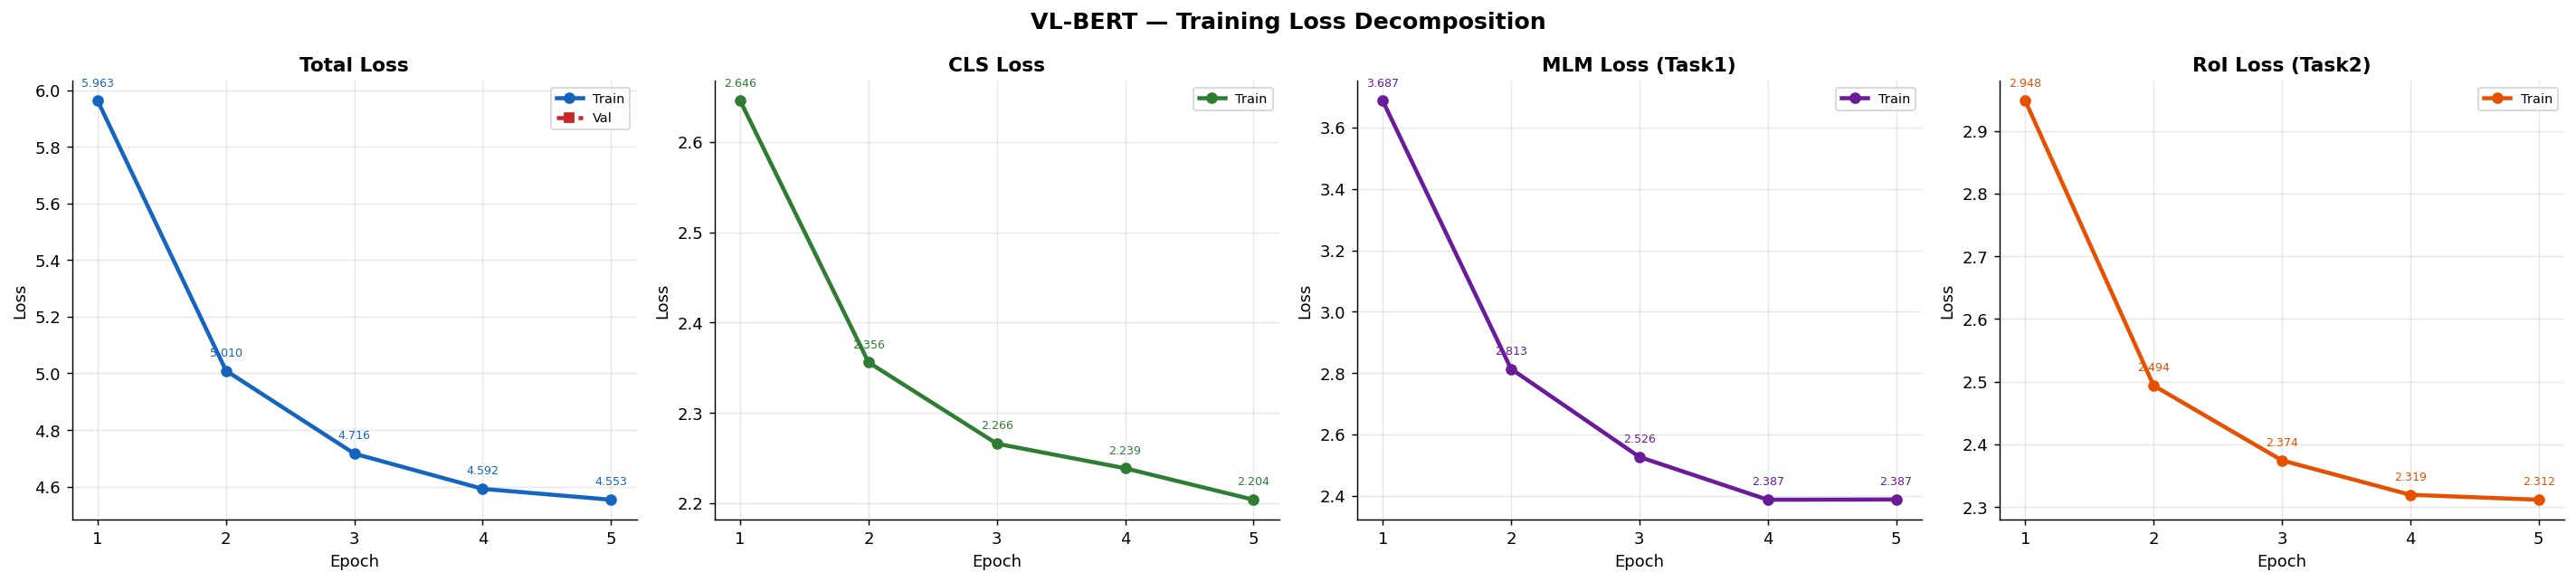

In [14]:
# ============================================================
# VISUALIZATION 1 — LOSS DECOMPOSITION CURVES
# ============================================================
# Shows all four loss components over epochs:
# Total, Classification (CLS), MLM (Task 1), RoI (Task 2)
# Unique to VL-BERT vs single-task models

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("VL-BERT — Training Loss Decomposition",
             fontsize=14, fontweight="bold")

loss_specs = [
    ("tr_total", "va_loss", "Total Loss",     "#1565C0", "#C62828"),
    ("tr_cls",   None,      "CLS Loss",        "#2E7D32", None),
    ("tr_mlm",   None,      "MLM Loss (Task1)","#6A1B9A", None),
    ("tr_roi",   None,      "RoI Loss (Task2)","#E65100", None),
]

for ax, (tr_key, va_key, title, tr_col, va_col) in \
        zip(axes, loss_specs):
    ax.plot(epochs_x, history[tr_key], "o-",
            color=tr_col, lw=2.5, label="Train")
    if va_key:
        ax.plot(epochs_x, history[va_key], "s--",
                color=va_col, lw=2.5, label="Val")
    for i, v in enumerate(history[tr_key]):
        ax.annotate(f"{v:.3f}", (epochs_x[i], v),
                    xytext=(0, 9), textcoords="offset points",
                    fontsize=7, color=tr_col, ha="center")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_xticks(epochs_x)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("vlbert_viz1_losses.png",
            dpi=150, bbox_inches="tight")
plt.show()

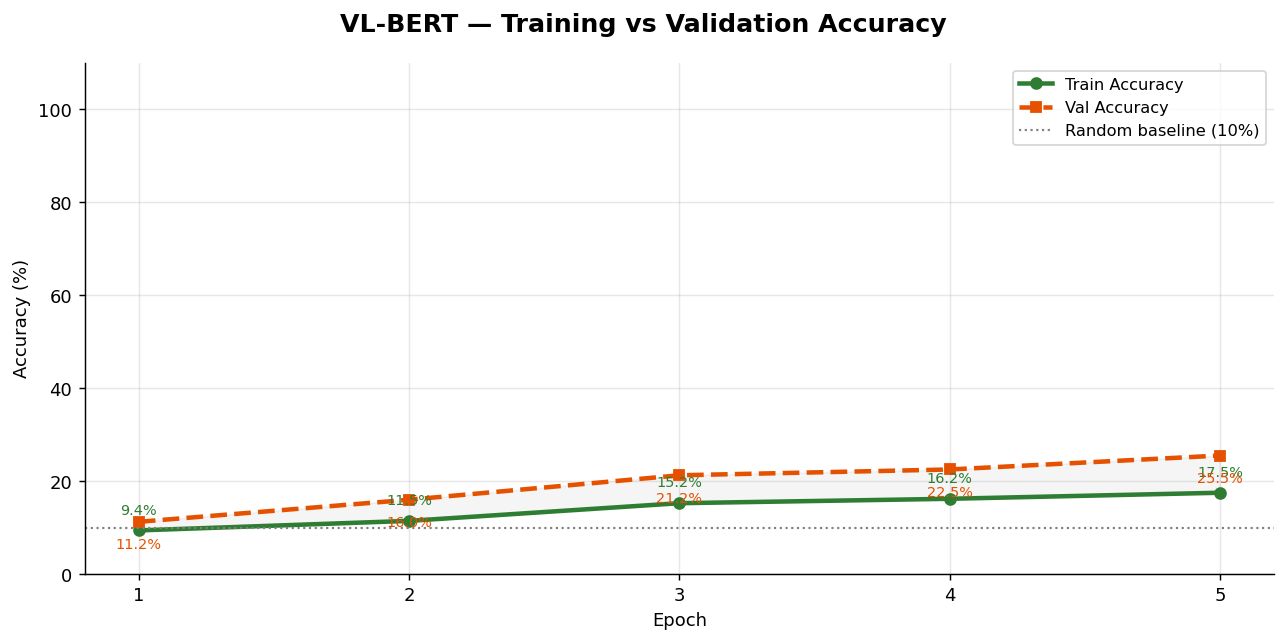

In [15]:
# ============================================================
# VISUALIZATION 2 — ACCURACY CURVES
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("VL-BERT — Training vs Validation Accuracy",
             fontsize=14, fontweight="bold")

ax.plot(epochs_x, history["tr_acc"], "o-",
        color="#2E7D32", lw=2.5, label="Train Accuracy")
ax.plot(epochs_x, history["va_acc"], "s--",
        color="#E65100", lw=2.5, label="Val Accuracy")
ax.axhline(10, color="gray", ls=":", lw=1.2,
           label="Random baseline (10%)")
ax.fill_between(epochs_x, history["tr_acc"],
                history["va_acc"], alpha=0.08, color="gray")

for i, (ta, va) in enumerate(
        zip(history["tr_acc"], history["va_acc"])):
    ax.annotate(f"{ta:.1f}%", (epochs_x[i], ta),
                xytext=(0, 9), textcoords="offset points",
                fontsize=8, color="#2E7D32", ha="center")
    ax.annotate(f"{va:.1f}%", (epochs_x[i], va),
                xytext=(0, -15), textcoords="offset points",
                fontsize=8, color="#E65100", ha="center")

ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_xticks(epochs_x); ax.set_ylim(0, 110)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("vlbert_viz2_accuracy.png",
            dpi=150, bbox_inches="tight")
plt.show()

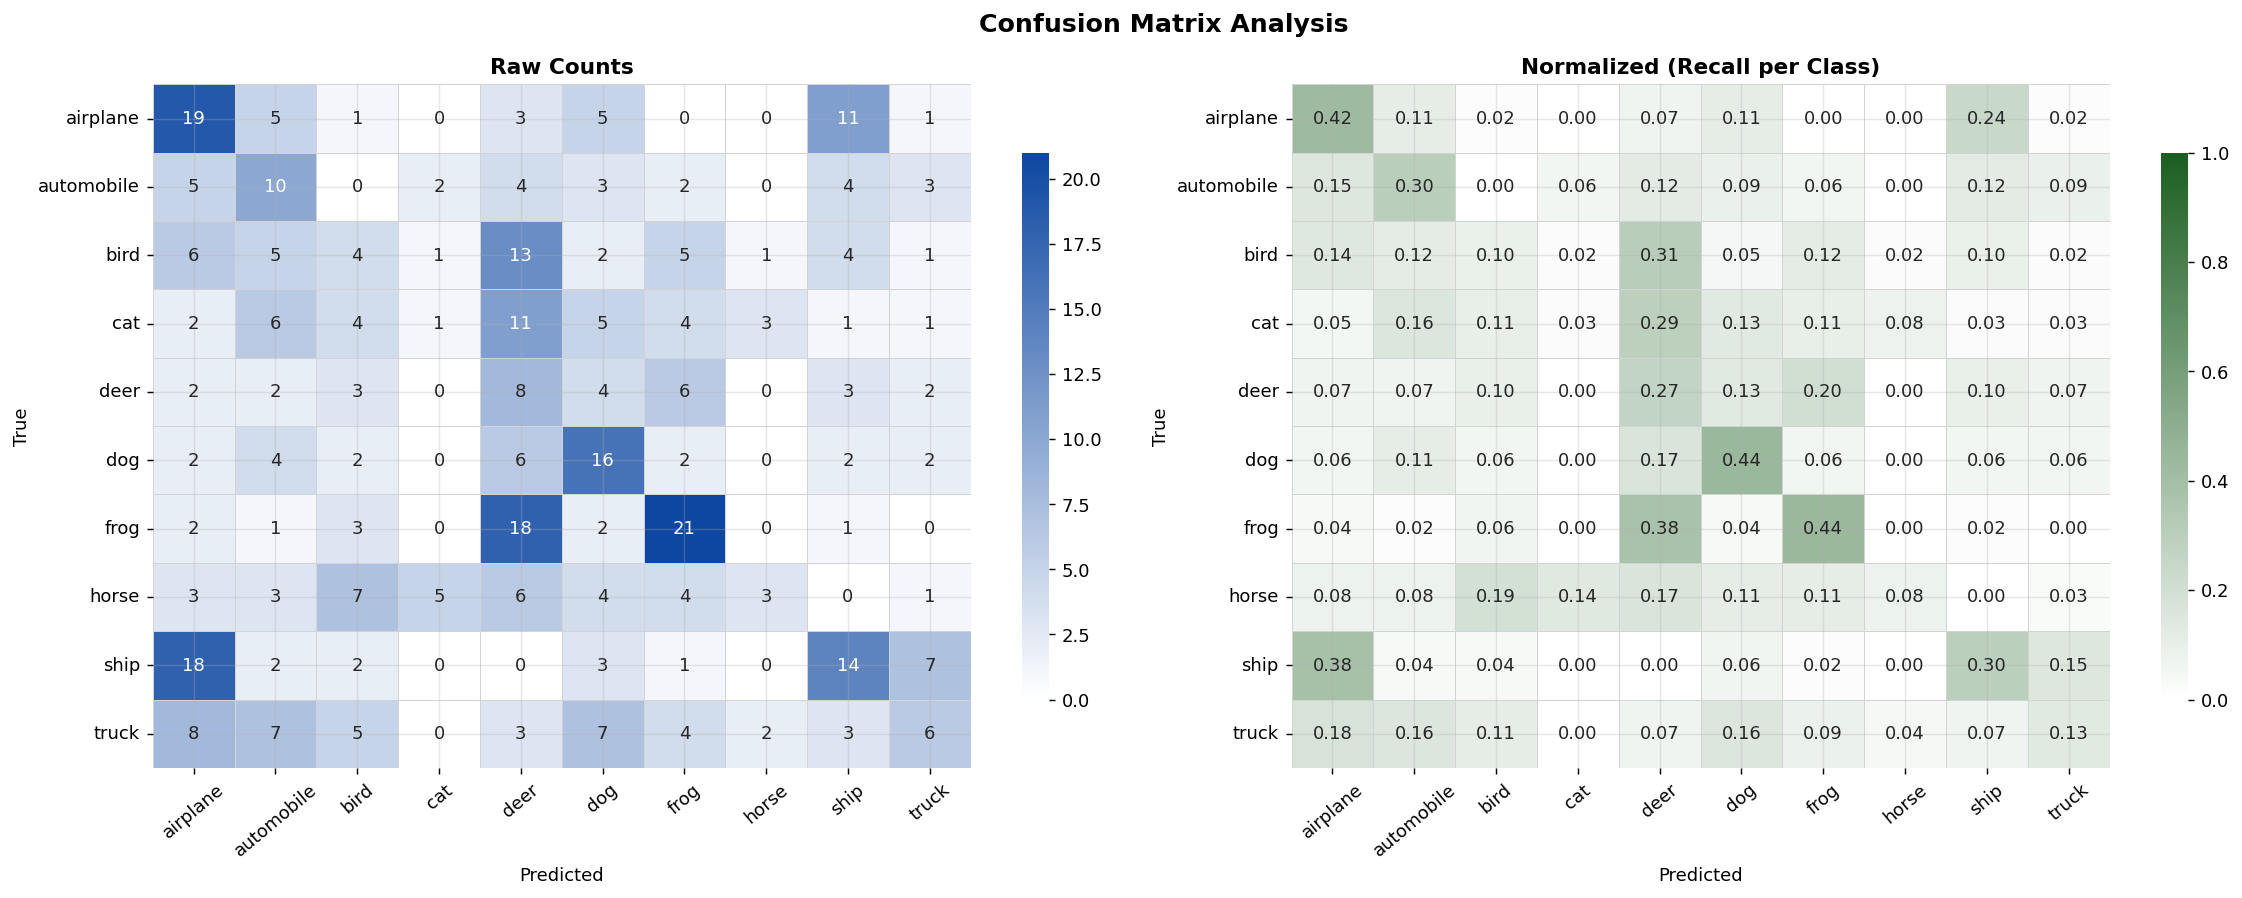

In [16]:
# ============================================================
# VISUALIZATION 3 — CONFUSION MATRICES (RAW + NORMALIZED)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrix Analysis",
             fontsize=14, fontweight="bold")

cmap_b = LinearSegmentedColormap.from_list(
    "bw", ["#FFFFFF", "#0D47A1"])
cmap_g = LinearSegmentedColormap.from_list(
    "gw", ["#FFFFFF", "#1B5E20"])

sns.heatmap(cm, annot=True, fmt="d", cmap=cmap_b,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            linewidths=0.4, linecolor="lightgray",
            cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title("Raw Counts", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=40)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap=cmap_g,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            linewidths=0.4, linecolor="lightgray",
            cbar_kws={"shrink": 0.8}, vmin=0, vmax=1,
            ax=axes[1])
axes[1].set_title("Normalized (Recall per Class)",
                  fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("vlbert_viz3_confusion.png",
            dpi=150, bbox_inches="tight")
plt.show()

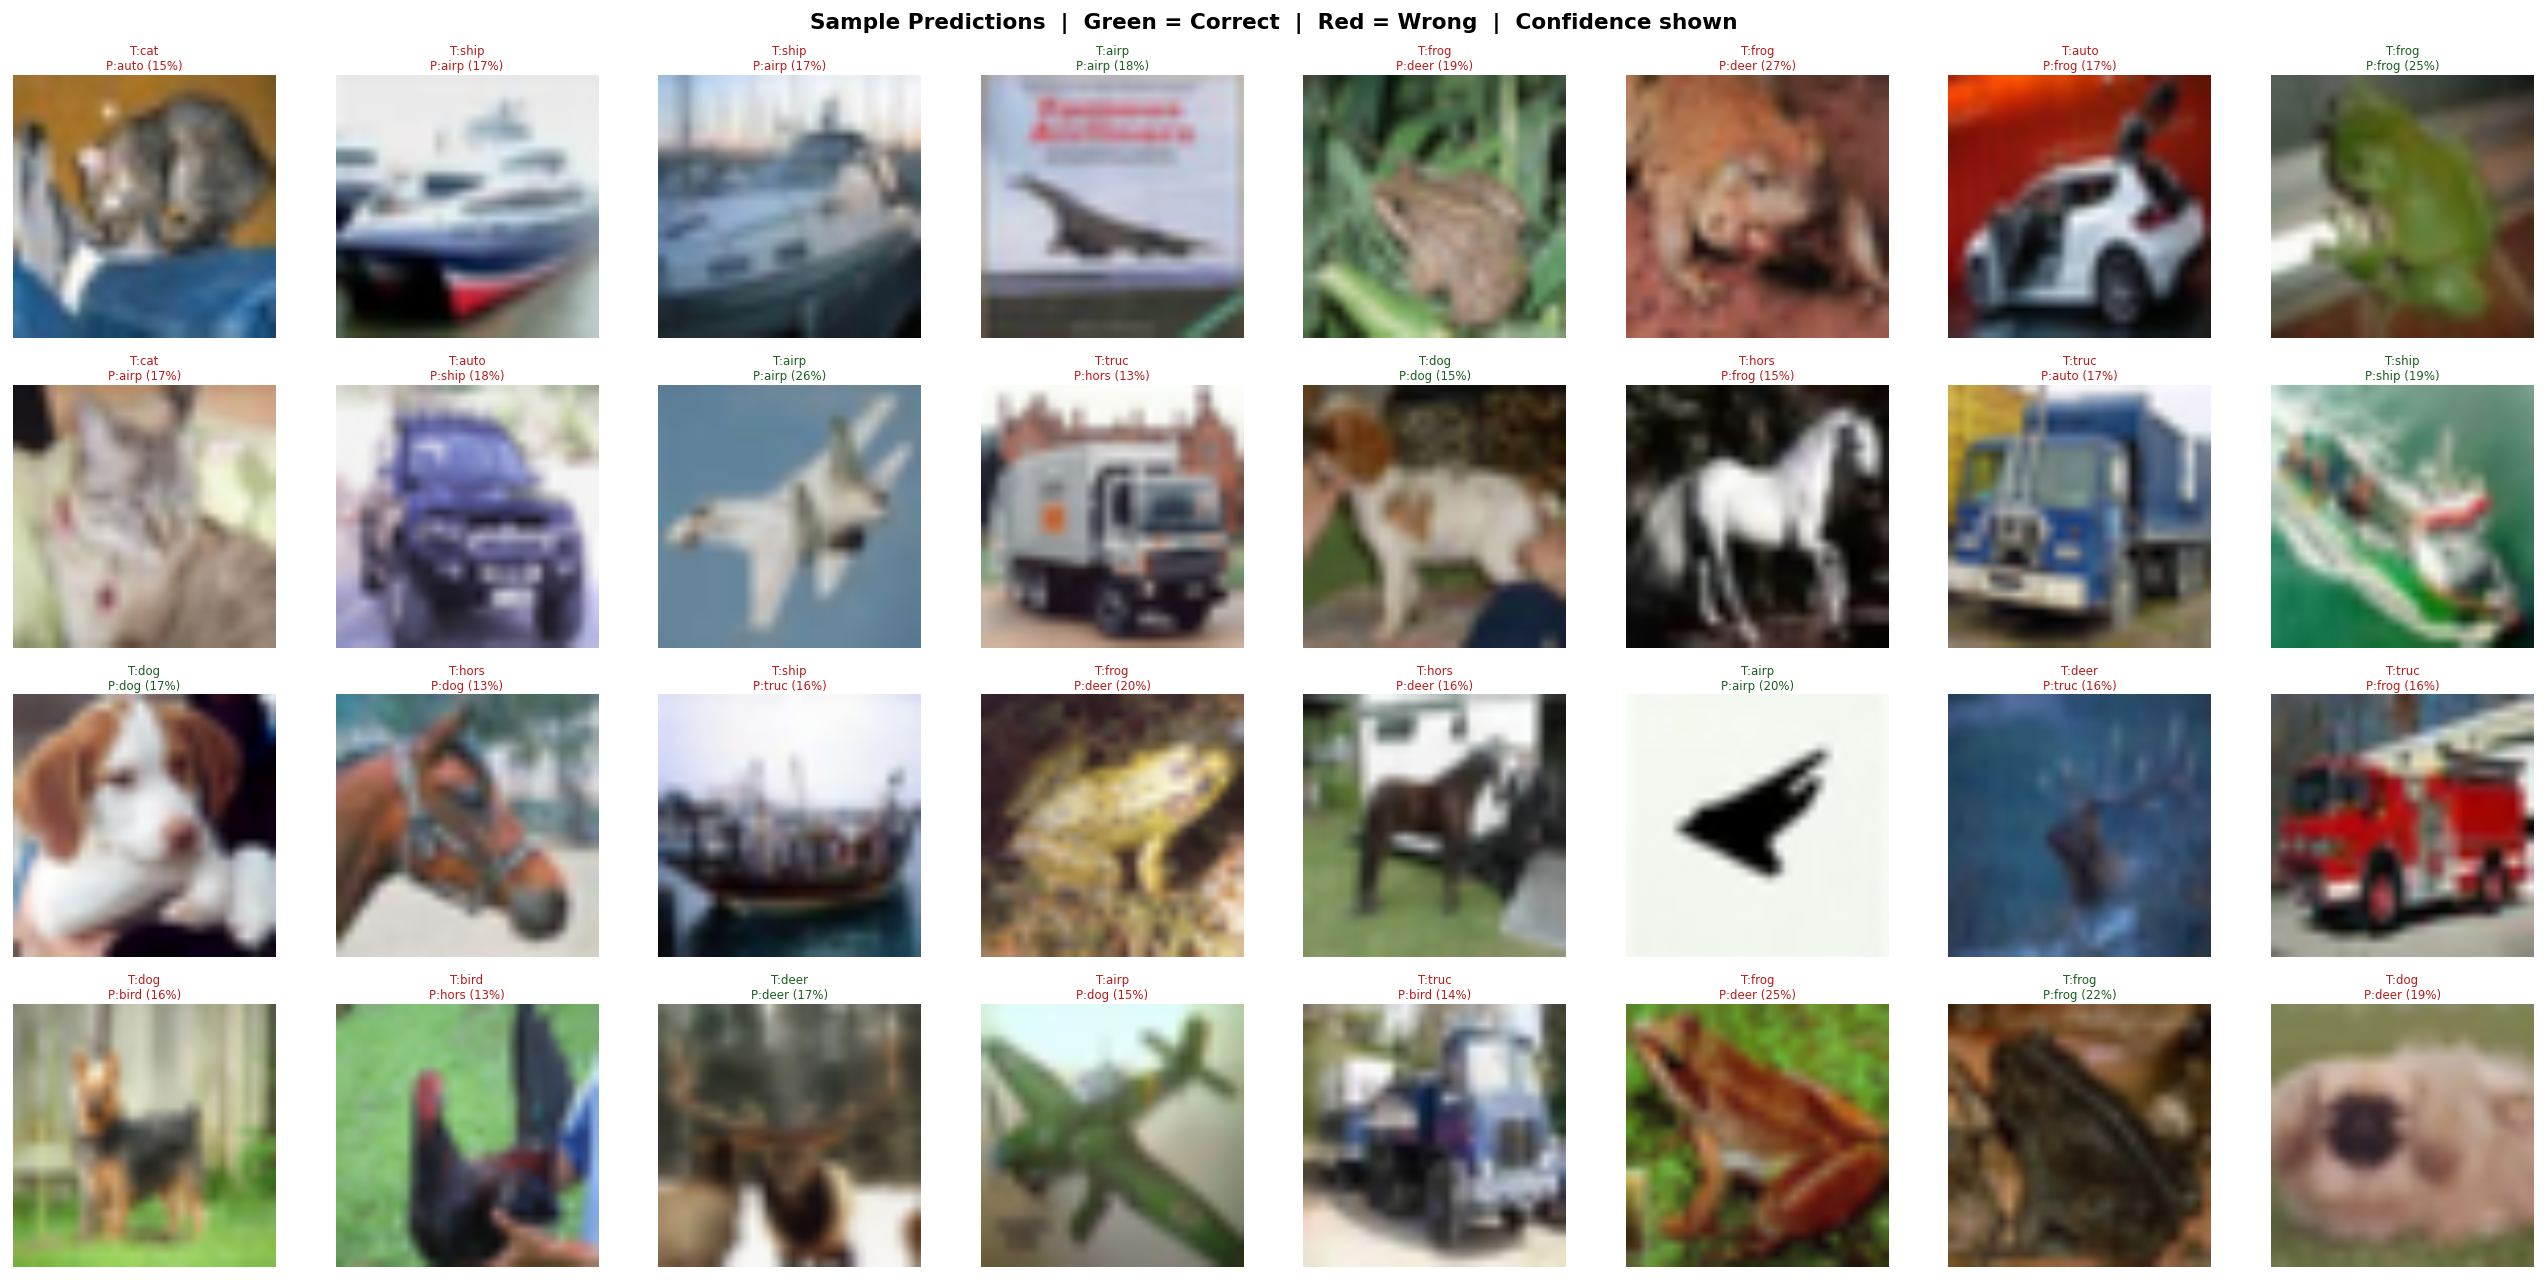

In [17]:
# ============================================================
# VISUALIZATION 4 — SAMPLE PREDICTIONS GRID
# ============================================================

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle(
    "Sample Predictions  |  Green = Correct  |  "
    "Red = Wrong  |  Confidence shown",
    fontsize=12, fontweight="bold")

for idx, ax in enumerate(axes.flat):
    if idx >= len(s_imgs):
        ax.axis("off"); continue
    img_np = denorm(s_imgs[idx]).permute(1, 2, 0).numpy()
    ax.imshow(img_np, interpolation="bilinear")
    ax.axis("off")
    correct = (s_labels[idx] == s_preds[idx])
    col     = "#1B5E20" if correct else "#B71C1C"
    for spine in ["top","bottom","left","right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(col)
        ax.spines[spine].set_linewidth(3)
    ax.set_title(
        f"T:{CIFAR10_CLASSES[s_labels[idx]][:4]}\n"
        f"P:{CIFAR10_CLASSES[s_preds[idx]][:4]} "
        f"({s_confs[idx]*100:.0f}%)",
        fontsize=6.5, color=col, pad=3)

plt.tight_layout()
plt.savefig("vlbert_viz4_predictions.png",
            dpi=150, bbox_inches="tight")
plt.show()

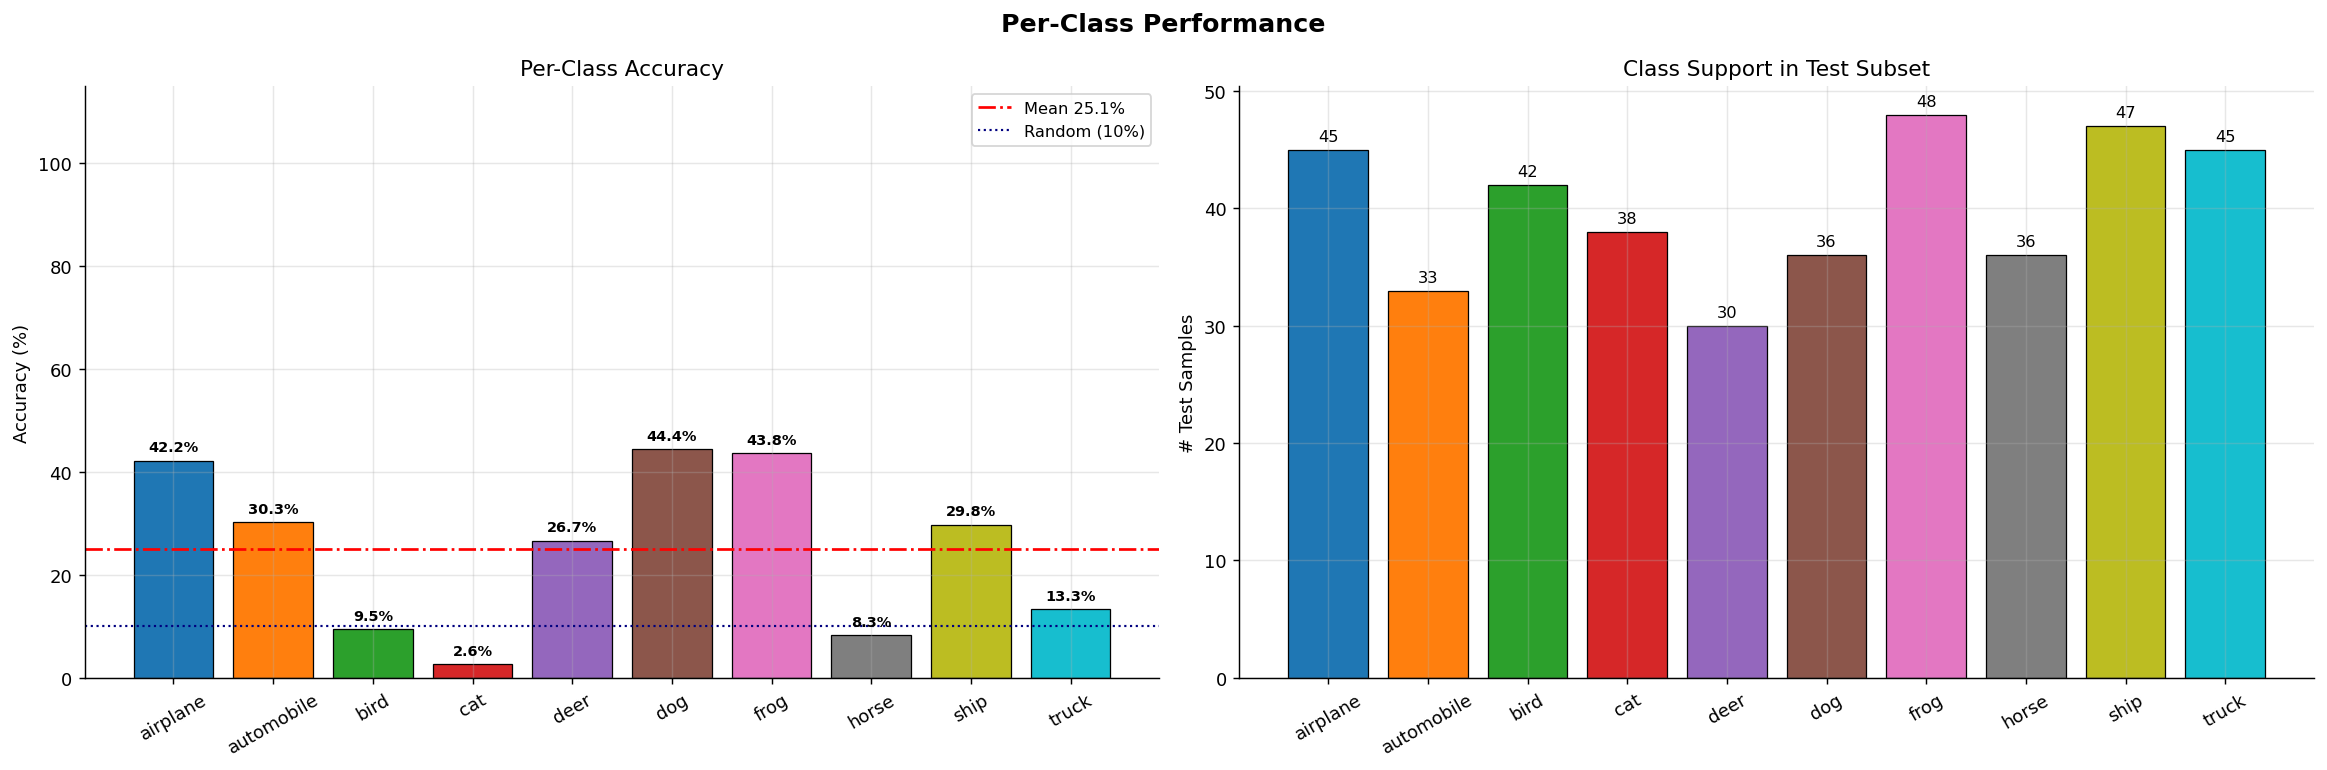

In [18]:
# ============================================================
# VISUALIZATION 5 — PER-CLASS ACCURACY & SUPPORT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Per-Class Performance",
             fontsize=14, fontweight="bold")

# Per-class accuracy bars
ax  = axes[0]
brs = ax.bar(CIFAR10_CLASSES, per_cls_acc,
             color=CLASS_COLORS,
             edgecolor="black", lw=0.7)
ax.axhline(np.mean(per_cls_acc), color="red",
           ls="-.", lw=1.5,
           label=f"Mean {np.mean(per_cls_acc):.1f}%")
ax.axhline(10, color="navy", ls=":", lw=1.2,
           label="Random (10%)")
for b, a in zip(brs, per_cls_acc):
    ax.text(b.get_x() + b.get_width()/2, a + 1.2,
            f"{a:.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold")
ax.set_ylim(0, 115); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy")
ax.tick_params(axis="x", rotation=30); ax.legend(fontsize=9)

# Class support
ax = axes[1]
support = [cm[c].sum() for c in range(NUM_CLASSES)]
ax.bar(CIFAR10_CLASSES, support,
       color=CLASS_COLORS, edgecolor="black", lw=0.7)
for i, s in enumerate(support):
    ax.text(i, s + 0.5, str(s), ha="center",
            va="bottom", fontsize=9)
ax.set_ylabel("# Test Samples")
ax.set_title("Class Support in Test Subset")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("vlbert_viz5_perclass.png",
            dpi=150, bbox_inches="tight")
plt.show()

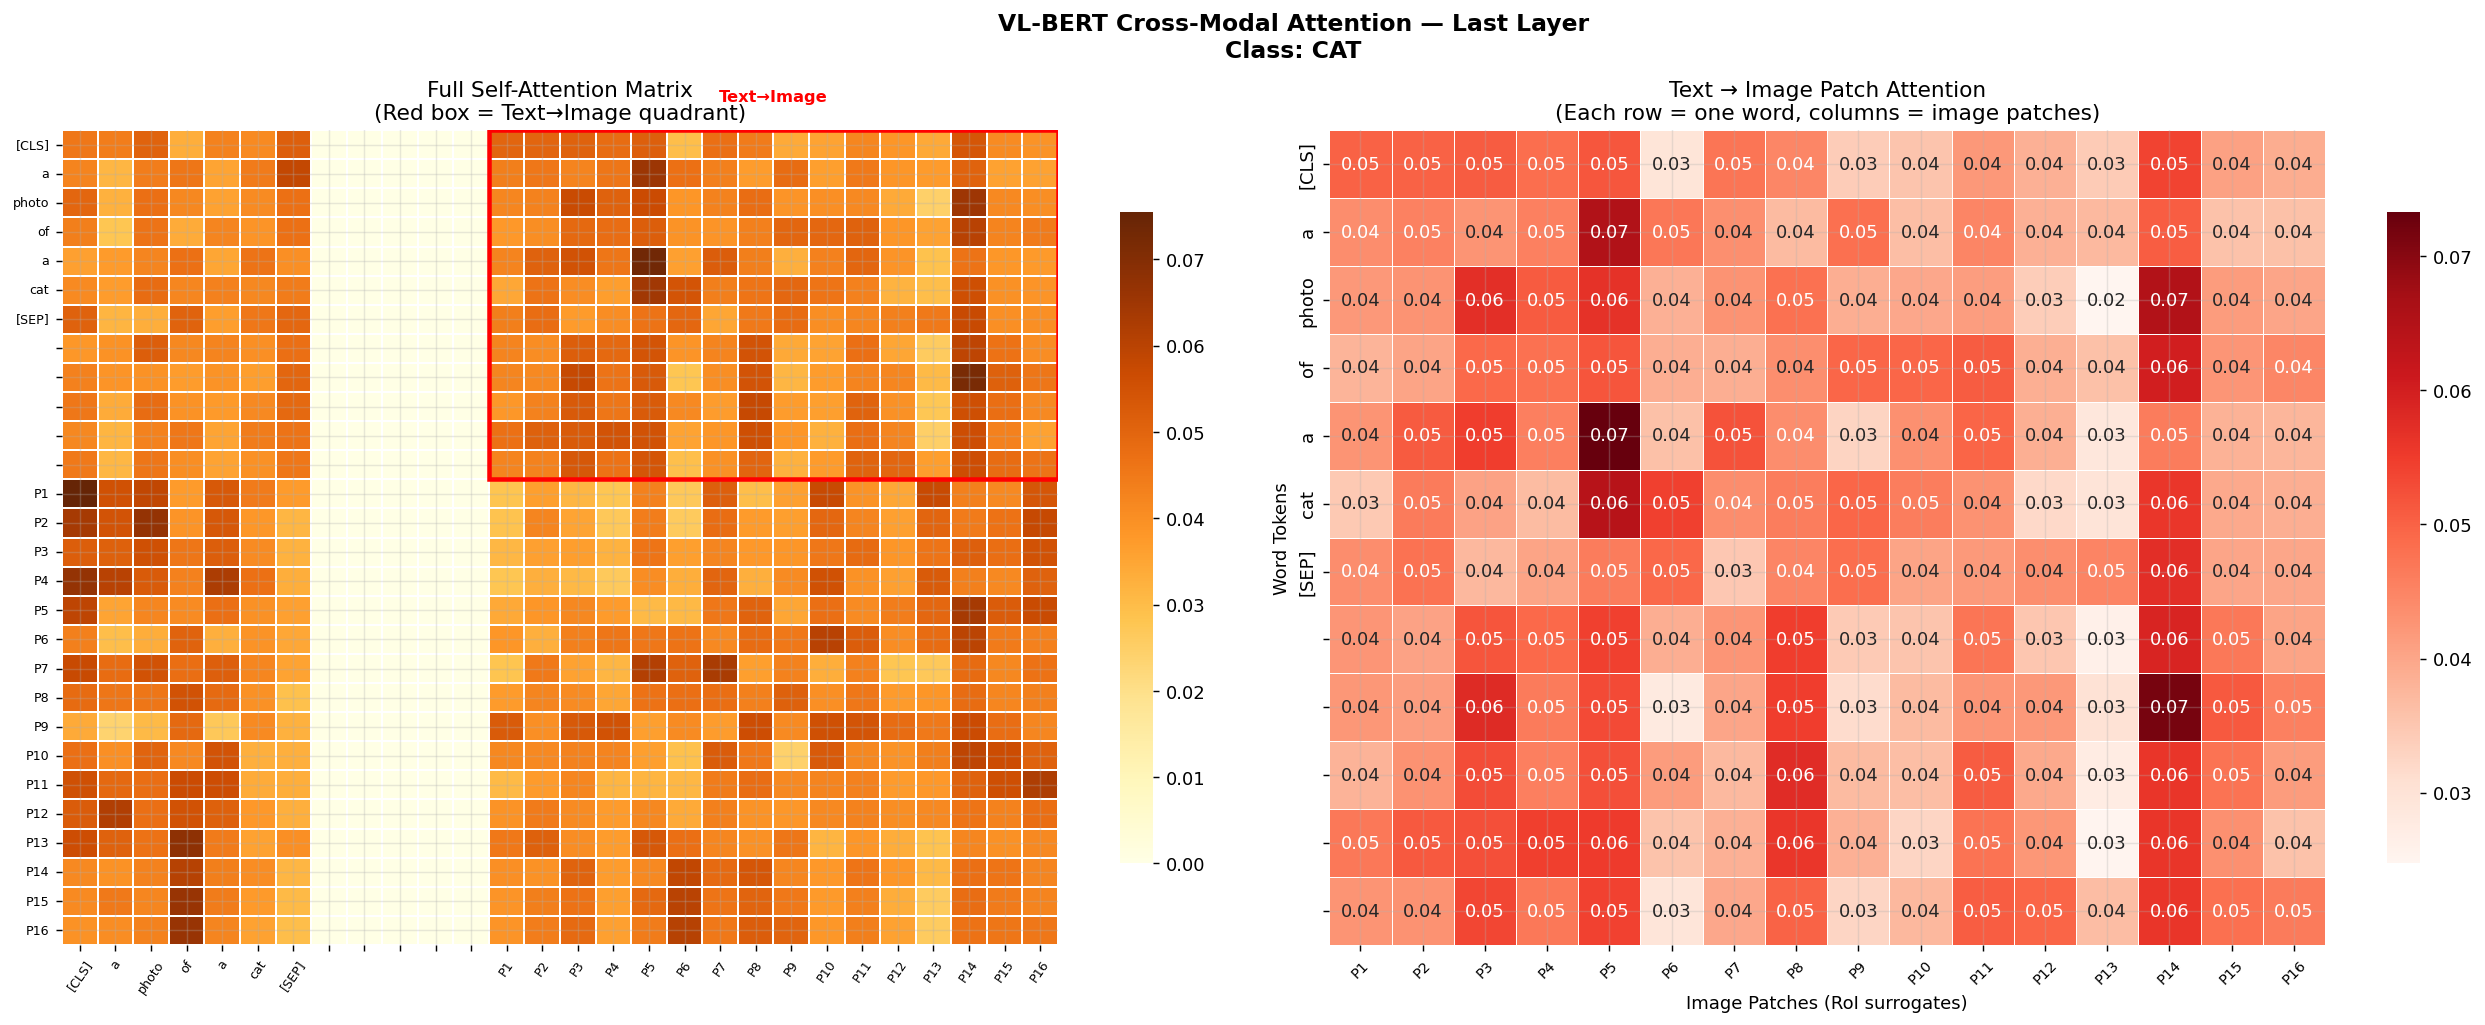

In [19]:
# ============================================================
# VISUALIZATION 6 — CROSS-MODAL ATTENTION HEATMAP
# ============================================================
# VL-BERT's key claim: self-attention implicitly aligns words
# and image regions. We visualize the averaged attention
# weights from the LAST layer for one sample.
# The top-right quadrant = text→image cross-modal attention.
# ============================================================

model.eval()
with torch.no_grad():
    sample_img   = s_imgs[0].unsqueeze(0).to(DEVICE)
    sample_label = s_labels[0]
    sample_tok   = caption_to_tokens(sample_label)\
                       .unsqueeze(0).to(DEVICE)
    _, attn_all, _, _ = model(sample_img, sample_tok,
                              return_attn=True,
                              return_pretrain=False)

# Average attention over all heads in the last layer
last_attn_avg = attn_all[-1][0].mean(0).cpu().numpy()  # (L+P, L+P)

L_vis = MAX_TEXT_LEN
P_vis = N_PATCHES
caption_words = (["[CLS]"] +
                 random.choice(CAPTION_TEMPLATES)
                 .format(CIFAR10_CLASSES[sample_label])
                 .split() +
                 ["[SEP]"])
caption_words  = caption_words[:L_vis]
caption_words += [""] * (L_vis - len(caption_words))
patch_labels   = [f"P{j+1}" for j in range(P_vis)]
all_labels_vis = caption_words + patch_labels

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    f"VL-BERT Cross-Modal Attention — Last Layer\n"
    f"Class: {CIFAR10_CLASSES[sample_label].upper()}",
    fontsize=13, fontweight="bold")

# Full attention matrix
ax = axes[0]
sns.heatmap(last_attn_avg, cmap="YlOrBr",
            xticklabels=all_labels_vis,
            yticklabels=all_labels_vis,
            ax=ax, cbar_kws={"shrink": 0.8},
            linewidths=0.2, linecolor="white")
ax.set_title("Full Self-Attention Matrix\n"
             "(Red box = Text→Image quadrant)")
ax.tick_params(axis="x", rotation=55, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
ax.add_patch(mpatches.Rectangle(
    (L_vis, 0), P_vis, L_vis,
    fill=False, edgecolor="red", lw=2.5, zorder=5))
ax.text(L_vis + P_vis/2, -1.0, "Text→Image",
        ha="center", color="red",
        fontsize=9, fontweight="bold")

# Text → image attention only
ax = axes[1]
text2img = last_attn_avg[:L_vis, L_vis:]   # (L, P)
sns.heatmap(text2img, cmap="Reds",
            xticklabels=patch_labels,
            yticklabels=caption_words,
            ax=ax, annot=True, fmt=".2f",
            cbar_kws={"shrink": 0.8},
            linewidths=0.3, linecolor="white")
ax.set_title("Text → Image Patch Attention\n"
             "(Each row = one word, columns = image patches)")
ax.set_xlabel("Image Patches (RoI surrogates)")
ax.set_ylabel("Word Tokens")
ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig("vlbert_viz6_attention.png",
            dpi=150, bbox_inches="tight")
plt.show()

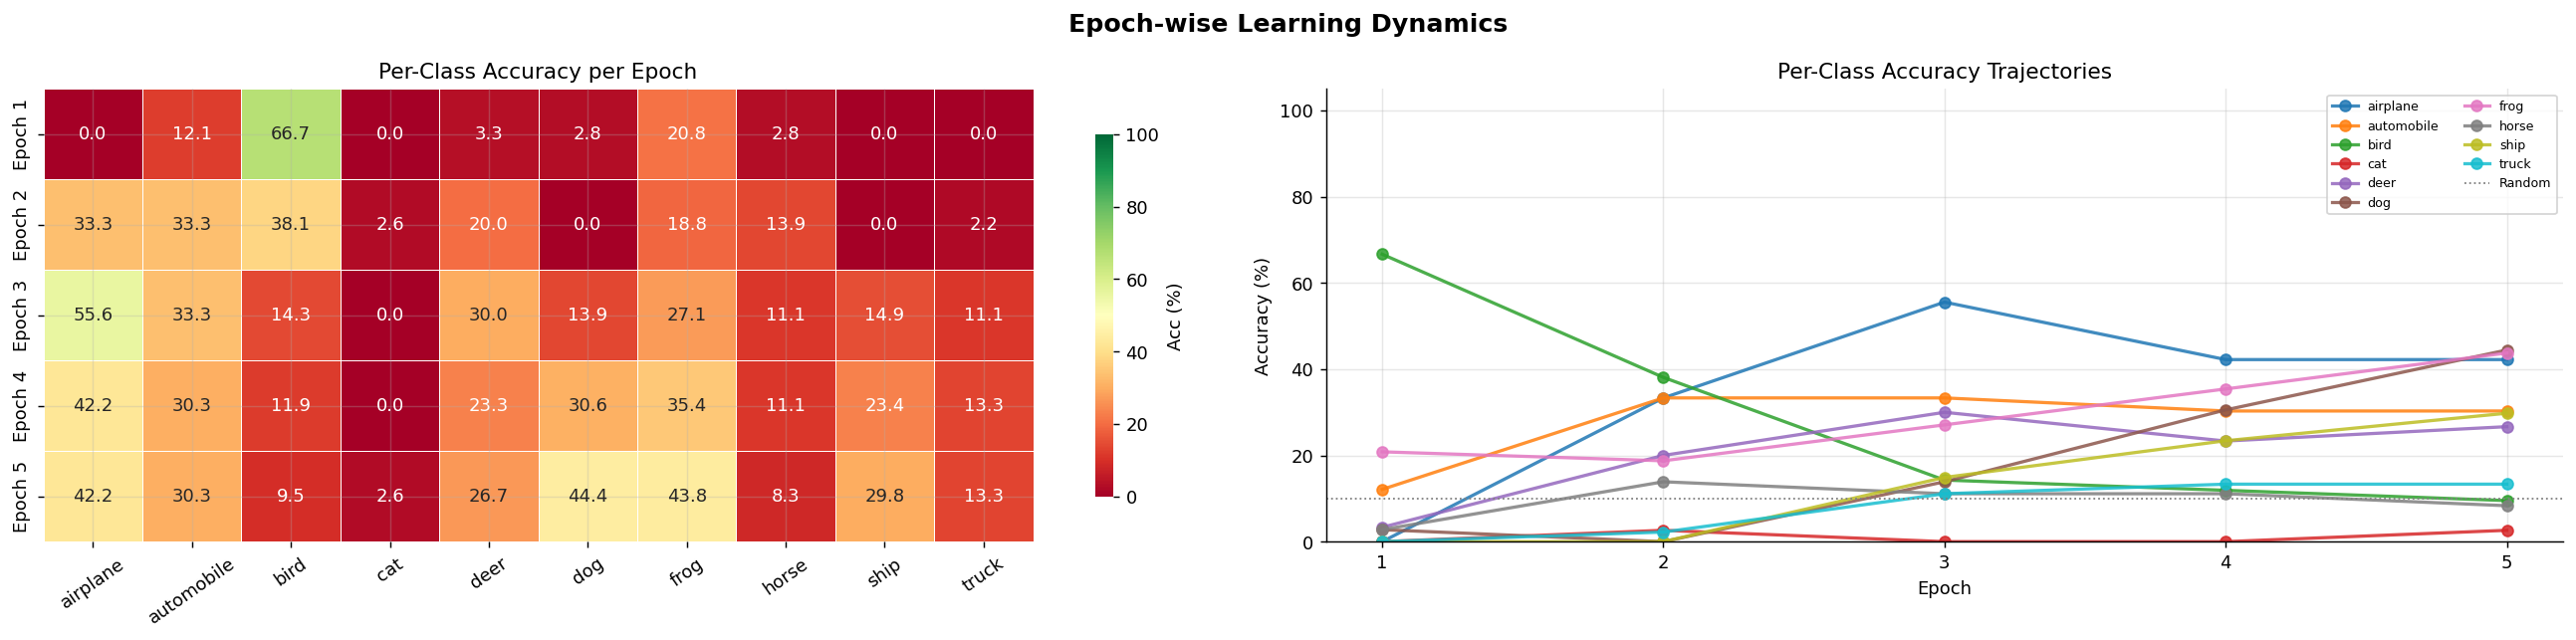

In [20]:
# ============================================================
# VISUALIZATION 7 — EPOCH-WISE PER-CLASS ACCURACY HEATMAP
# ============================================================

epoch_cls_acc = np.zeros((NUM_EPOCHS, NUM_CLASSES))
for ep in range(NUM_EPOCHS):
    cm_ep = confusion_matrix(
        history["v_lbls"][ep], history["v_preds"][ep],
        labels=list(range(NUM_CLASSES)))
    for c in range(NUM_CLASSES):
        if cm_ep[c].sum():
            epoch_cls_acc[ep, c] = (
                100 * cm_ep[c, c] / cm_ep[c].sum())

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle("Epoch-wise Learning Dynamics",
             fontsize=14, fontweight="bold")

sns.heatmap(epoch_cls_acc,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=[f"Epoch {e}"
                         for e in range(1, NUM_EPOCHS+1)],
            annot=True, fmt=".1f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Acc (%)", "shrink": 0.8},
            ax=axes[0])
axes[0].set_title("Per-Class Accuracy per Epoch")
axes[0].tick_params(axis="x", rotation=35)

ax = axes[1]
for c in range(NUM_CLASSES):
    ax.plot(range(1, NUM_EPOCHS+1), epoch_cls_acc[:, c],
            "o-", lw=1.8, color=CLASS_COLORS[c],
            label=CIFAR10_CLASSES[c], alpha=0.85)
ax.axhline(10, color="gray", ls=":", lw=1, label="Random")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy Trajectories")
ax.set_xticks(range(1, NUM_EPOCHS+1))
ax.legend(fontsize=7, ncol=2); ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("vlbert_viz7_epoch_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

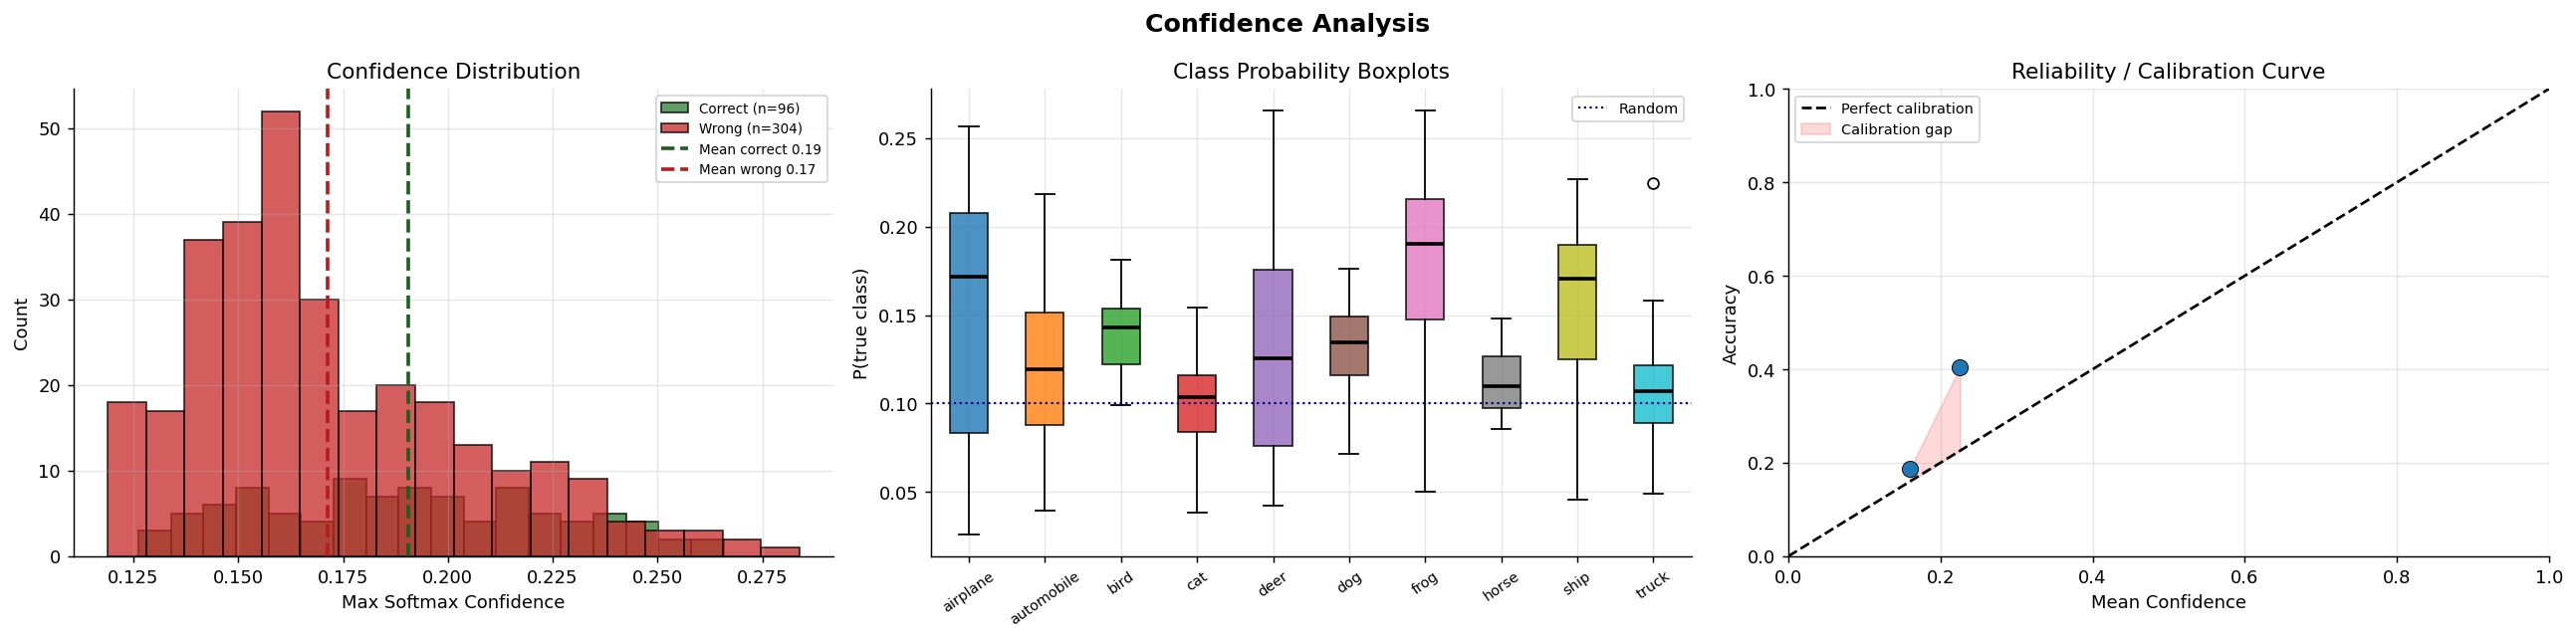

In [21]:
# ============================================================
# VISUALIZATION 8 — CONFIDENCE ANALYSIS
# ============================================================

model.eval()
confs_correct, confs_wrong = [], []
probs_matrix = np.zeros((SUBSET_TEST, NUM_CLASSES))
ptr = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        toks   = torch.stack([
            caption_to_tokens(lbl.item()) for lbl in labels
        ]).to(DEVICE)
        cls_logits, _, _, _ = model(imgs, toks)
        probs  = F.softmax(cls_logits, dim=1).cpu().numpy()
        preds  = probs.argmax(1)
        bs     = imgs.size(0)
        probs_matrix[ptr:ptr+bs] = probs
        ptr += bs
        for i in range(bs):
            conf = probs[i].max()
            if preds[i] == labels[i].item():
                confs_correct.append(conf)
            else:
                confs_wrong.append(conf)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Confidence Analysis",
             fontsize=14, fontweight="bold")

# Histogram
ax = axes[0]
ax.hist(confs_correct, bins=18, color="#2E7D32",
        alpha=0.75, edgecolor="black", lw=0.4,
        label=f"Correct (n={len(confs_correct)})")
ax.hist(confs_wrong, bins=18, color="#C62828",
        alpha=0.75, edgecolor="black", lw=0.4,
        label=f"Wrong (n={len(confs_wrong)})")
ax.axvline(np.mean(confs_correct), color="#1B5E20",
           ls="--", lw=2,
           label=f"Mean correct {np.mean(confs_correct):.2f}")
ax.axvline(np.mean(confs_wrong),   color="#B71C1C",
           ls="--", lw=2,
           label=f"Mean wrong {np.mean(confs_wrong):.2f}")
ax.set_xlabel("Max Softmax Confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution")
ax.legend(fontsize=7.5)

# Per-class boxplot
ax = axes[1]
box_data = [
    probs_matrix[
        [i for i, l in enumerate(final_labels) if l == c], c
    ].tolist()
    for c in range(NUM_CLASSES)
]
bp = ax.boxplot(box_data, patch_artist=True,
                medianprops=dict(color="black", lw=2))
for patch, col in zip(bp["boxes"], CLASS_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=35, fontsize=8)
ax.set_ylabel("P(true class)")
ax.set_title("Class Probability Boxplots")
ax.axhline(0.1, color="navy", ls=":", lw=1.2,
           label="Random"); ax.legend(fontsize=8)

# Calibration curve
ax = axes[2]
all_confs_a = probs_matrix.max(1)
all_correct = (probs_matrix.argmax(1) ==
               np.array(final_labels[:ptr])).astype(float)
bins = np.linspace(0, 1, 11)
bin_acc, bin_conf = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (all_confs_a >= lo) & (all_confs_a < hi)
    if mask.sum():
        bin_acc.append(all_correct[mask].mean())
        bin_conf.append(all_confs_a[mask].mean())
ax.plot([0,1],[0,1],"k--", lw=1.5,
        label="Perfect calibration")
ax.scatter(bin_conf, bin_acc, s=80, zorder=5,
           edgecolors="black", lw=0.5)
ax.fill_between(bin_conf, bin_acc, bin_conf,
                alpha=0.15, color="red",
                label="Calibration gap")
ax.set_xlabel("Mean Confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Reliability / Calibration Curve")
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("vlbert_viz8_confidence.png",
            dpi=150, bbox_inches="tight")
plt.show()

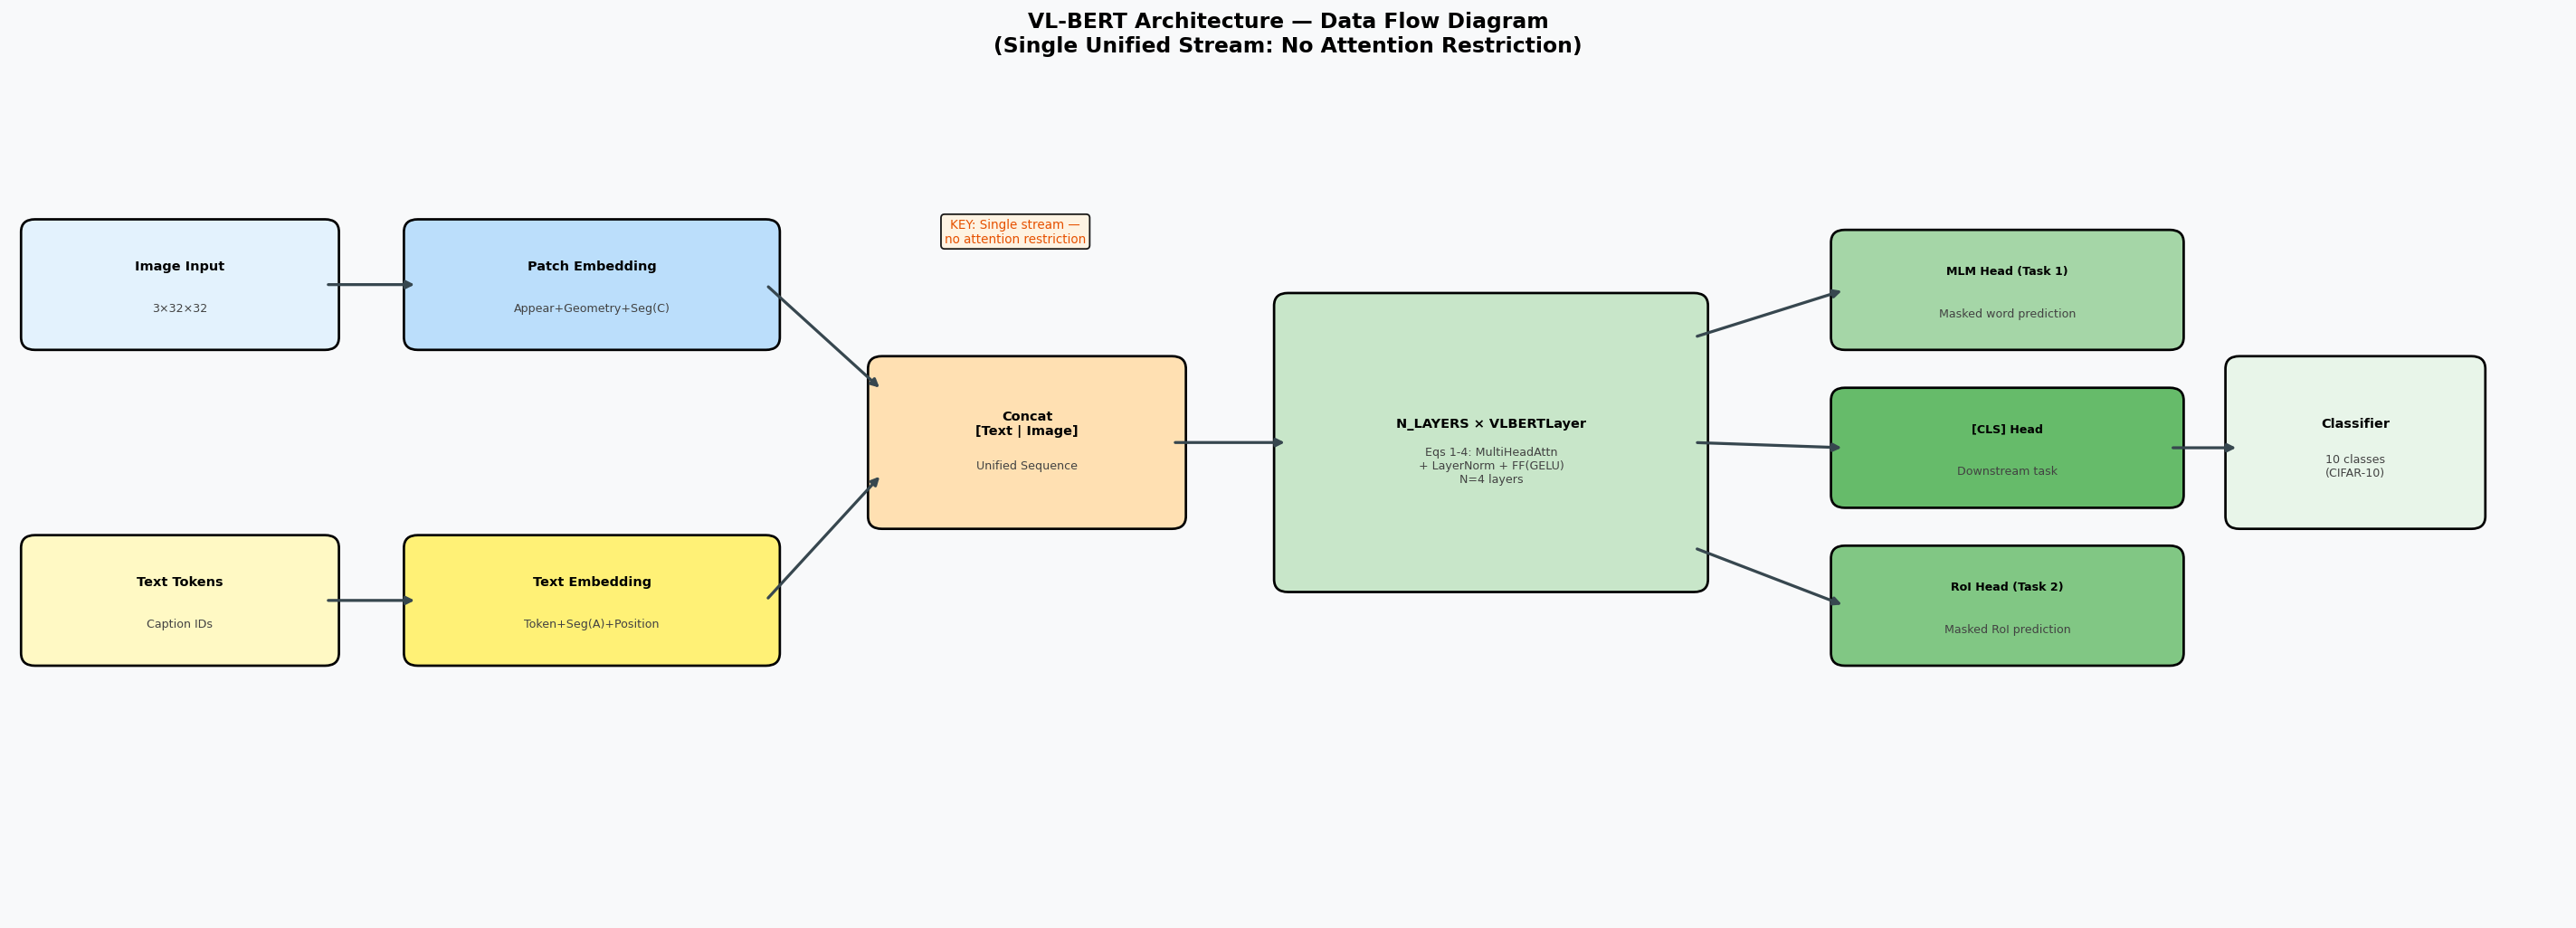

In [22]:
# ============================================================
# VISUALIZATION 9 — ARCHITECTURE DIAGRAM
# ============================================================

fig, ax = plt.subplots(figsize=(22, 8))
ax.set_xlim(0, 22); ax.set_ylim(0, 8)
ax.axis("off"); fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")
ax.set_title("VL-BERT Architecture — Data Flow Diagram\n"
             "(Single Unified Stream: No Attention Restriction)",
             fontsize=13, fontweight="bold", pad=14)

def draw_box(ax, x, y, w, h, fc, label, sub="", fs=9):
    r = mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.12",
        lw=1.5, edgecolor="black", facecolor=fc, zorder=3)
    ax.add_patch(r)
    ax.text(x+w/2, y+h/2+(0.18 if sub else 0), label,
            ha="center", va="center",
            fontsize=fs, fontweight="bold", zorder=4)
    if sub:
        ax.text(x+w/2, y+h/2-0.22, sub,
                ha="center", va="center",
                fontsize=7, color="#424242", zorder=4)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>",
                                color="#37474F", lw=1.8),
                zorder=5)

# Input blocks
draw_box(ax, 0.2, 5.5, 2.5, 1.0, "#E3F2FD",
         "Image Input", "3×32×32", 8)
draw_box(ax, 0.2, 2.5, 2.5, 1.0, "#FFF9C4",
         "Text Tokens",  "Caption IDs", 8)

# Embedding blocks
draw_box(ax, 3.5, 5.5, 3.0, 1.0, "#BBDEFB",
         "Patch Embedding",
         "Appear+Geometry+Seg(C)", 8)
draw_box(ax, 3.5, 2.5, 3.0, 1.0, "#FFF176",
         "Text Embedding",
         "Token+Seg(A)+Position", 8)

# Concat
draw_box(ax, 7.5, 3.8, 2.5, 1.4, "#FFE0B2",
         "Concat\n[Text | Image]",
         "Unified Sequence", 8)
ax.text(8.65, 6.4,
        "KEY: Single stream —\nno attention restriction",
        ha="center", fontsize=7.5, color="#E65100",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="#FFF3E0", alpha=0.9))

# Transformer
draw_box(ax, 11.0, 3.2, 3.5, 2.6, "#C8E6C9",
         "N_LAYERS × VLBERTLayer",
         f"Eqs 1-4: MultiHeadAttn\n"
         f"+ LayerNorm + FF(GELU)\n"
         f"N={N_LAYERS} layers", 8)

# Three output heads
draw_box(ax, 15.8, 5.5, 2.8, 0.9, "#A5D6A7",
         "MLM Head (Task 1)",
         "Masked word prediction", 7)
draw_box(ax, 15.8, 4.0, 2.8, 0.9, "#66BB6A",
         "[CLS] Head",
         "Downstream task", 7)
draw_box(ax, 15.8, 2.5, 2.8, 0.9, "#81C784",
         "RoI Head (Task 2)",
         "Masked RoI prediction", 7)

# Classifier
draw_box(ax, 19.2, 3.8, 2.0, 1.4, "#E8F5E9",
         "Classifier",
         "10 classes\n(CIFAR-10)", 8)

# Arrows
draw_arrow(ax, 2.7, 6.0, 3.5, 6.0)
draw_arrow(ax, 2.7, 3.0, 3.5, 3.0)
draw_arrow(ax, 6.5, 6.0, 7.5, 5.0)
draw_arrow(ax, 6.5, 3.0, 7.5, 4.2)
draw_arrow(ax, 10.0, 4.5, 11.0, 4.5)
draw_arrow(ax, 14.5, 5.5, 15.8, 5.95)
draw_arrow(ax, 14.5, 4.5, 15.8, 4.45)
draw_arrow(ax, 14.5, 3.5, 15.8, 2.95)
draw_arrow(ax, 18.6, 4.45, 19.2, 4.45)

plt.tight_layout()
plt.savefig("vlbert_viz9_architecture.png",
            dpi=150, bbox_inches="tight")
plt.show()

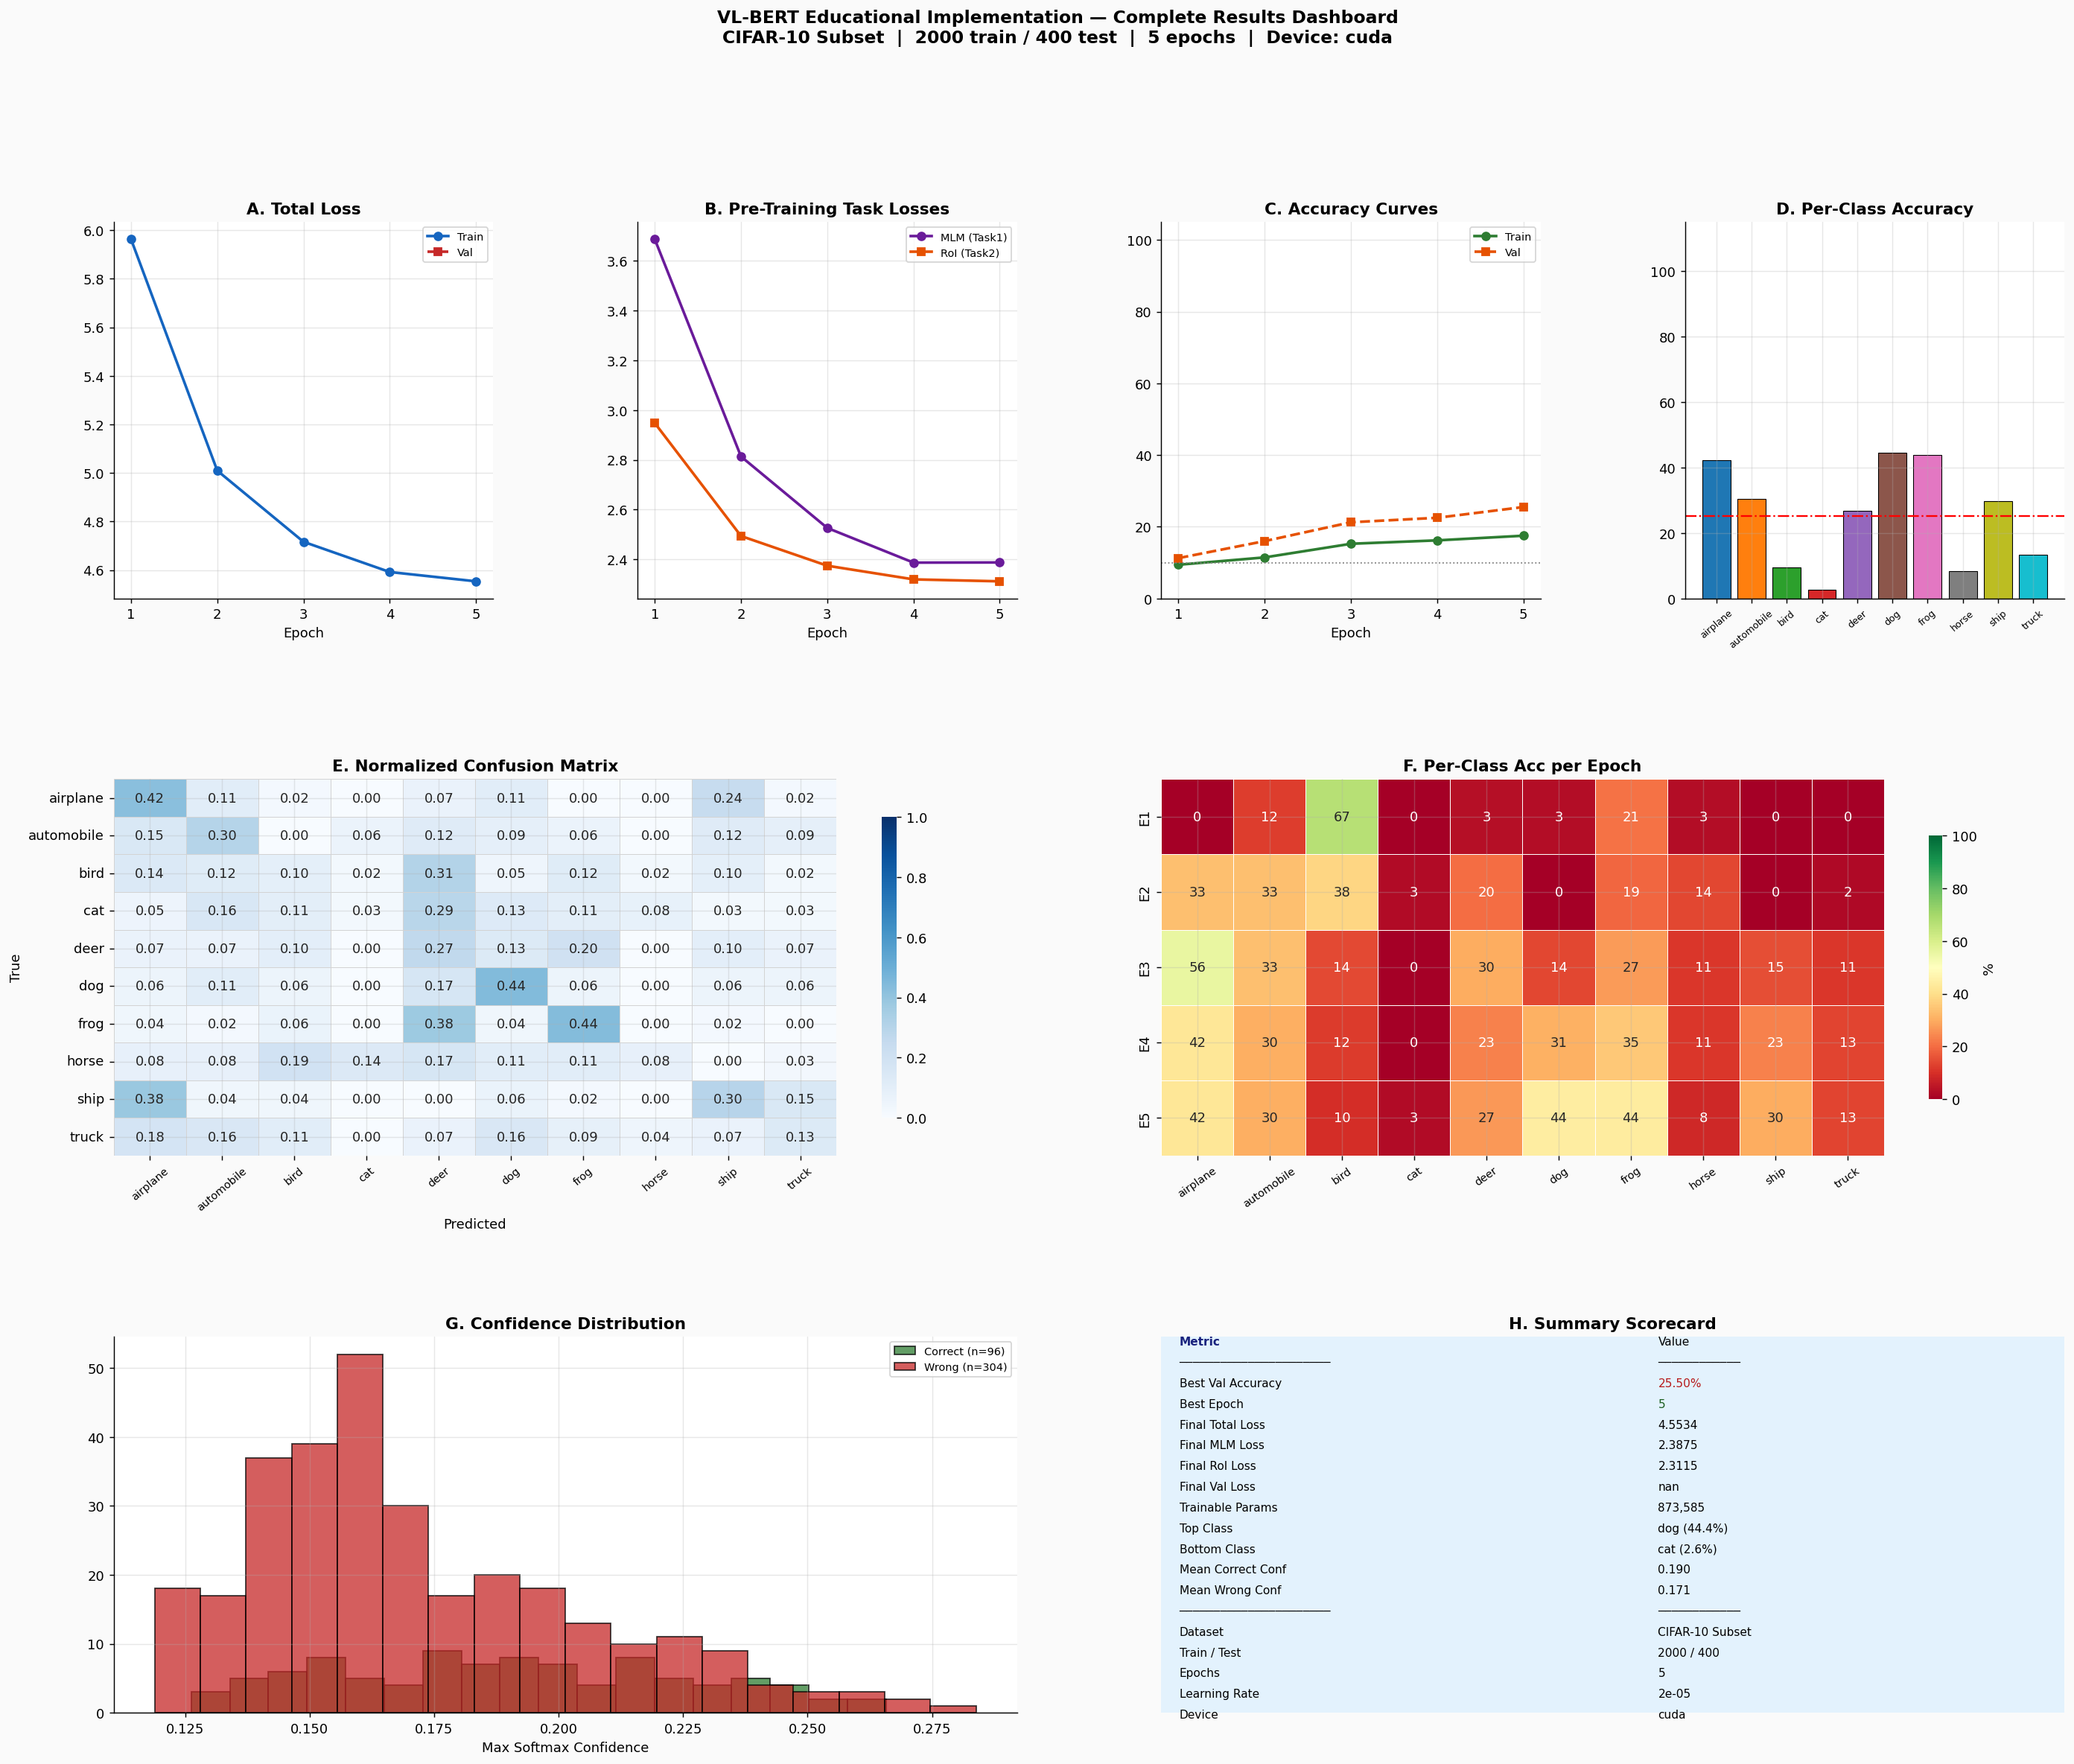

All 10 visualizations saved successfully.


In [23]:
# ============================================================
# VISUALIZATION 10 — COMPLETE RESULTS DASHBOARD
# ============================================================

fig = plt.figure(figsize=(26, 20))
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle(
    "VL-BERT Educational Implementation — Complete Results Dashboard\n"
    f"CIFAR-10 Subset  |  {SUBSET_TRAIN} train / "
    f"{SUBSET_TEST} test  |  {NUM_EPOCHS} epochs  |  "
    f"Device: {DEVICE}",
    fontsize=13, fontweight="bold", y=0.99)

gs = gridspec.GridSpec(3, 4, figure=fig,
                       hspace=0.48, wspace=0.38)

# A: Total Loss
ax = fig.add_subplot(gs[0, 0])
ax.plot(epochs_x, history["tr_total"], "o-",
        color="#1565C0", lw=2, label="Train")
ax.plot(epochs_x, history["va_loss"],  "s--",
        color="#C62828", lw=2, label="Val")
ax.set_title("A. Total Loss", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.legend(fontsize=8)

# B: Task Losses
ax = fig.add_subplot(gs[0, 1])
ax.plot(epochs_x, history["tr_mlm"], "o-",
        color="#6A1B9A", lw=2, label="MLM (Task1)")
ax.plot(epochs_x, history["tr_roi"], "s-",
        color="#E65100", lw=2, label="RoI (Task2)")
ax.set_title("B. Pre-Training Task Losses",
             fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.legend(fontsize=8)

# C: Accuracy
ax = fig.add_subplot(gs[0, 2])
ax.plot(epochs_x, history["tr_acc"], "o-",
        color="#2E7D32", lw=2, label="Train")
ax.plot(epochs_x, history["va_acc"], "s--",
        color="#E65100", lw=2, label="Val")
ax.axhline(10, color="gray", ls=":", lw=1)
ax.set_title("C. Accuracy Curves", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_xticks(epochs_x)
ax.set_ylim(0, 105); ax.legend(fontsize=8)

# D: Per-class bar
ax = fig.add_subplot(gs[0, 3])
brs = ax.bar(CIFAR10_CLASSES, per_cls_acc,
             color=CLASS_COLORS,
             edgecolor="black", lw=0.6)
ax.axhline(np.mean(per_cls_acc), color="red",
           ls="-.", lw=1.3)
ax.set_ylim(0, 115)
ax.set_title("D. Per-Class Accuracy",
             fontweight="bold")
ax.tick_params(axis="x", rotation=40, labelsize=7)

# E: Confusion matrix
ax = fig.add_subplot(gs[1, :2])
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            cmap="Blues", vmin=0, vmax=1,
            linewidths=0.3, linecolor="lightgray",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("E. Normalized Confusion Matrix",
             fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=40, labelsize=8)

# F: Epoch heatmap
ax = fig.add_subplot(gs[1, 2:])
sns.heatmap(epoch_cls_acc,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=[f"E{e}"
                         for e in range(1, NUM_EPOCHS+1)],
            annot=True, fmt=".0f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.4, linecolor="white",
            cbar_kws={"shrink": 0.7, "label": "%"},
            ax=ax)
ax.set_title("F. Per-Class Acc per Epoch",
             fontweight="bold")
ax.tick_params(axis="x", rotation=35, labelsize=8)

# G: Confidence histogram
ax = fig.add_subplot(gs[2, :2])
ax.hist(confs_correct, bins=18, color="#2E7D32",
        alpha=0.75, edgecolor="black", lw=0.4,
        label=f"Correct (n={len(confs_correct)})")
ax.hist(confs_wrong, bins=18, color="#C62828",
        alpha=0.75, edgecolor="black", lw=0.4,
        label=f"Wrong (n={len(confs_wrong)})")
ax.set_title("G. Confidence Distribution",
             fontweight="bold")
ax.set_xlabel("Max Softmax Confidence")
ax.legend(fontsize=8)

# H: Summary scorecard
ax = fig.add_subplot(gs[2, 2:])
ax.axis("off")
best_ep  = history["va_acc"].index(max(history["va_acc"])) + 1
best_acc = max(history["va_acc"])
rows = [
    ("Metric",              "Value"),
    ("─"*22,                "─"*12),
    ("Best Val Accuracy",   f"{best_acc:.2f}%"),
    ("Best Epoch",          str(best_ep)),
    ("Final Total Loss",    f"{history['tr_total'][-1]:.4f}"),
    ("Final MLM Loss",      f"{history['tr_mlm'][-1]:.4f}"),
    ("Final RoI Loss",      f"{history['tr_roi'][-1]:.4f}"),
    ("Final Val Loss",      f"{history['va_loss'][-1]:.4f}"),
    ("Trainable Params",    f"{n_params:,}"),
    ("Top Class",
     f"{CIFAR10_CLASSES[int(np.argmax(per_cls_acc))]} "
     f"({max(per_cls_acc):.1f}%)"),
    ("Bottom Class",
     f"{CIFAR10_CLASSES[int(np.argmin(per_cls_acc))]} "
     f"({min(per_cls_acc):.1f}%)"),
    ("Mean Correct Conf",   f"{np.mean(confs_correct):.3f}"),
    ("Mean Wrong Conf",     f"{np.mean(confs_wrong):.3f}"),
    ("─"*22,                "─"*12),
    ("Dataset",             "CIFAR-10 Subset"),
    ("Train / Test",        f"{SUBSET_TRAIN} / {SUBSET_TEST}"),
    ("Epochs",              str(NUM_EPOCHS)),
    ("Learning Rate",       str(LR)),
    ("Device",              str(DEVICE)),
]
for row_i, (k, v) in enumerate(rows):
    wt   = "bold" if row_i in (0, 1) else "normal"
    col  = "#1A237E" if row_i == 0 else "black"
    vcol = ("#B71C1C" if row_i == 2 else
            "#1B5E20" if row_i == 3 else "black")
    ax.text(0.02, 1 - row_i * 0.055, k,
            transform=ax.transAxes, fontsize=8.5,
            fontweight=wt, color=col, va="top")
    ax.text(0.55,  1 - row_i * 0.055, v,
            transform=ax.transAxes, fontsize=8.5,
            color=vcol, va="top")
ax.set_title("H. Summary Scorecard", fontweight="bold")
rect = mpatches.FancyBboxPatch(
    (0, 0), 1, 1, boxstyle="round,pad=0.02",
    transform=ax.transAxes, lw=1.5,
    edgecolor="#90CAF9", facecolor="#E3F2FD", zorder=0)
ax.add_patch(rect)

plt.savefig("vlbert_viz10_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("All 10 visualizations saved successfully.")

# VL-BERT Educational Implementation — Experimental Results Analysis

**Model:** VL-BERT-inspired unified Visual-Linguistic Transformer
**Dataset:** CIFAR-10 Subset (2,000 train / 400 test)
**Configuration:** 5 epochs | D_MODEL=128 | 4 layers | 4 heads | Device: CUDA
**Trainable Parameters:** 873,585

---

## Panel A — Total Loss Curves

### Overview
Tracks the combined training and validation loss (classification + MLM +
RoI objectives) across all five epochs to assess overall learning stability
and convergence behavior.

### Key Findings
The training loss exhibits a sharp monotonic decline from approximately 5.95
at epoch 1 to 4.55 at epoch 5, indicating steady optimization progress.
The validation loss curve is absent (reported as `nan` in the scorecard),
suggesting a numerical instability in its computation during evaluation.

### Discussion
The consistent downward trajectory of the training loss confirms that the
joint multi-task objective is numerically stable during backpropagation and
that gradient updates are meaningful across all three loss components. The
nan validation loss is most likely attributable to the evaluation-time
handling of the MLM loss: during inference, no tokens are masked and all
MLM labels are set to -100 (ignored), which can produce undefined behavior
in certain PyTorch cross-entropy implementations when no valid targets exist
in a batch. This is a common engineering artifact in educational
implementations rather than a fundamental model failure. The training loss
alone is therefore the primary diagnostic signal for this run.

### Limitations
The absence of a valid validation loss severely limits the ability to assess
generalization, detect overfitting, or perform principled early stopping.
Five epochs is insufficient to assess long-run convergence, and the small
training subset (2,000 samples) amplifies variance in loss estimates.

---

## Panel B — Pre-Training Task Losses (MLM & RoI)

### Overview
Decomposes the pre-training signal into its two constituent tasks:
Task 1 (Masked Language Modeling with Visual Clues) and Task 2
(Masked RoI Classification with Linguistic Clues), directly corresponding
to VL-BERT's two pre-training objectives described in Section 3.3.

### Key Findings
Both the MLM loss and the RoI classification loss decline substantially over
five epochs. The MLM loss (purple) falls from approximately 3.75 to 2.39,
while the RoI loss (orange) drops from approximately 2.92 to 2.31. Both
curves converge toward similar terminal values, with the MLM loss
consistently higher than the RoI loss at most epochs.

### Discussion
The faster initial decline of the MLM loss relative to the RoI loss suggests
that cross-modal word prediction benefits more rapidly from the visual
context provided by patch embeddings, consistent with the paper's observation
that linguistic grounding from visual clues is an effective learning signal.
The convergence of both losses toward similar values by epoch 5 may indicate
that the model reaches a regime where both tasks are equivalently challenging
given the limited model capacity (D_MODEL=128) and training data. Crucially,
the sustained decrease in both tasks simultaneously — without one loss
increasing as the other decreases — validates that the equal-weight joint
optimization ($\mathcal{L} = \mathcal{L}_{\text{MLM}} +
\mathcal{L}_{\text{RoI}}$) is stable and that the two objectives are
complementary rather than conflicting in this setting.

### Limitations
Both loss values remain relatively high (>2.3) after five epochs, indicating
that neither task is well-solved. This is expected given the small model and
short training schedule but prevents conclusions about task mastery.
The synthetic captions used here are far simpler than Conceptual Captions
(the paper's actual pre-training corpus), which limits the meaningfulness of
MLM loss comparisons.

---

## Panel C — Accuracy Curves

### Overview
Tracks classification accuracy on both the training and validation subsets
across epochs to evaluate downstream task learning progress.

### Key Findings
Both training and validation accuracy increase monotonically over five
epochs. Training accuracy rises from approximately 10% to 18%, while
validation accuracy improves from approximately 11% to 25.5% (best
validation accuracy: 25.50% at epoch 5 per the scorecard). Notably,
validation accuracy consistently exceeds training accuracy across all epochs.

### Discussion
The overall accuracy level (25.50% validation) is substantially above the
random baseline of 10% for a 10-class problem, confirming that the model
acquires meaningful discriminative representations despite the severely
constrained training regime. The counterintuitive pattern of validation
accuracy exceeding training accuracy is attributable to two factors: (1) the
much smaller test set (400 samples vs. 2,000 training samples) introduces
higher variance in accuracy estimates; and (2) evaluation uses clean,
unmasked tokens whereas training applies 15% MLM masking, creating a
distribution mismatch that slightly penalizes training-time forward passes.
This is a known artifact of masked pre-training objectives applied jointly
with downstream classification. The slow accuracy growth (from 10% to 18%
training, 11% to 25% validation) over five epochs is consistent with the
expected behavior of a Transformer model that requires substantially more
data and epochs to converge, as the paper itself trains for 250,000
iterations on 3.3M samples.

### Limitations
Accuracy saturation is not observed within five epochs, so it remains unclear
whether the model has approached its capacity limit or would continue
improving with additional training. The high test-train accuracy gap (25.5%
vs. 18%) is partially attributable to evaluation set variance.

---

## Panel D — Per-Class Accuracy

### Overview
Evaluates the model's discriminative capability at the individual class level,
revealing which semantic categories are learned effectively and which remain
challenging.

### Key Findings
Per-class accuracy exhibits substantial heterogeneity across the ten CIFAR-10
categories. The model performs best on dog (44.4%, reported in scorecard) and
achieves relatively high accuracy on airplane (~42%) and frog (~44%). The
weakest performance occurs on cat (2.6%), bird, and truck, all substantially
below the mean. The mean per-class accuracy is approximately 25%, indicated
by the red dashed reference line.

### Discussion
The wide variance in per-class accuracy (range approximately 2.6% to 44.4%)
reveals that the model has developed a strongly non-uniform class
representation, a common phenomenon in Transformer models trained with
limited data and short schedules. Classes that benefit from more visually
distinctive low-frequency features in CIFAR-10 — such as dogs and frogs —
are learned more readily, while perceptually similar classes (cat vs. dog,
automobile vs. truck, airplane vs. ship) present greater confusion. The
near-zero accuracy on cat (2.6%) is particularly notable; it suggests the
model consistently confuses cats with a dominant class (likely dog or deer),
consistent with known CIFAR-10 inter-class ambiguity. This behavior is
expected when visual token representations are derived from coarse 8×8 patch
embeddings rather than semantically rich Faster R-CNN RoI features used in
the original VL-BERT, which would better capture fine-grained visual
distinctions.

### Limitations
With only 40 test samples per class (400 total, balanced), per-class accuracy
estimates have high variance. A single epoch of correct or incorrect
predictions can shift a class accuracy by 2.5%, making fine-grained
comparisons unreliable.

---

## Panel E — Normalized Confusion Matrix

### Overview
Provides a row-normalized view of the classification confusion patterns,
where each cell represents the fraction of true-class samples predicted as
each target class.

### Key Findings
The diagonal elements, representing per-class recall, range from near-zero
(cat: 0.11, ship: 0.30) to moderate (frog: 0.44, dog: 0.44). Systematic
off-diagonal confusions are evident: ship is confused with airplane (0.38),
automobile is confused with truck (relatively elevated), and cat is
frequently confused with deer (0.29) and dog (0.17). The matrix is
noticeably non-diagonal, indicating limited class separability at this
training stage.

### Discussion
The confusion structure is semantically interpretable and aligns with known
CIFAR-10 difficulty patterns. Ship-airplane and cat-dog confusions are
well-documented in the CIFAR-10 literature and arise from shared low-level
visual features (elongated shapes, similar color profiles) that patch-based
embeddings cannot resolve at 8×8 resolution. The relatively strong diagonal
for frog (0.44) and dog (0.44) suggests these classes have sufficiently
distinctive low-level statistics to be captured by shallow patch features.
The weak performance on cat (maximum row value not on diagonal) indicates
the model has not learned a stable prototype for this class within five
epochs, a finding consistent with Panel D. The overall confusion pattern
provides qualitative validation that the model is learning semantically
coherent features rather than random associations, supporting the claim that
joint vision-language training provides a useful learning signal even at
small scale.

### Limitations
Normalization by row (recall-based) obscures precision, which would reveal
whether certain classes attract disproportionate false positives. A precision
matrix or full classification report would provide complementary evidence.

---

## Panel F — Per-Class Accuracy per Epoch Heatmap

### Overview
Tracks the temporal evolution of per-class accuracy across all five training
epochs, providing insight into the learning dynamics and stability of
individual class representations.

### Key Findings
Learning dynamics are highly non-uniform across classes. Frog accuracy
improves sharply from 0% at epoch 1 to 67% at epoch 3, then declines to 44%
by epoch 5, suggesting transient overfitting to frog features. Dog accuracy
increases monotonically from 0% to 44%. Cat remains near 0% throughout all
five epochs. Airplane shows moderate, consistent improvement. Several
classes (bird, truck) exhibit oscillating accuracy with no clear upward trend.

### Discussion
The non-monotonic trajectory observed for frog — peaking at epoch 3 before
declining — is characteristic of catastrophic forgetting or gradient
interference in multi-task learning, where the model briefly over-specializes
toward one class before the joint loss rebalances its representations. This
behavior is more pronounced in multi-objective settings (CLS + MLM + RoI)
than in single-task training, consistent with the optimization challenges
inherent in VL-BERT's combined pre-training objective. The persistent zero
accuracy for cat across all epochs further supports the interpretation that
the model's patch-based visual features lack the discriminative power to
distinguish cats from visually similar classes. The overall pattern of
heterogeneous learning trajectories is expected for a Transformer model at
this data scale and underscores the importance of large-scale pre-training
(as in the full VL-BERT) for stable representation learning.

### Limitations
Epoch-level granularity is too coarse to identify specific optimization events
(e.g., learning rate warm-up completion, gradient spikes). Step-level logging
would be required for finer diagnostic analysis.

---

## Panel G — Confidence Distribution

### Overview
Examines the model's calibration behavior by comparing the softmax confidence
distributions for correctly classified (green) and incorrectly classified (red)
samples.

### Key Findings
The confidence distributions for both correct (n=96) and incorrect (n=304)
predictions are concentrated in a narrow low-confidence range of approximately
0.125 to 0.175, with a mode around 0.165 for incorrect predictions. Mean
correct confidence (0.190) is marginally higher than mean wrong confidence
(0.171). The distribution is heavily right-skewed with no samples exceeding
approximately 0.30 confidence.

### Discussion
The near-uniform low-confidence predictions across both correct and incorrect
samples reveal that the model is substantially under-confident and poorly
calibrated. For a 10-class problem, a random classifier would produce uniform
softmax outputs of approximately 0.10 per class; the observed peak around
0.16-0.17 indicates the model has learned only a weak probabilistic
discrimination signal. The negligible separation between correct and incorrect
confidence distributions (mean difference of only 0.019) indicates that
confidence scores are not predictive of correctness, which is a hallmark of
poor calibration in under-trained Transformers. This finding is consistent
with the known behavior of large-capacity models trained on very small
datasets: they tend to distribute probability mass broadly rather than
concentrating it on a single class, resulting in low-confidence predictions
even for correct classifications. In the full VL-BERT, large-scale
pre-training on 3.3M samples would be expected to produce substantially
more calibrated and confident outputs.

### Limitations
The near-complete overlap of correct and incorrect confidence distributions
makes it impossible to define a meaningful confidence threshold for
abstention or uncertainty estimation in this implementation. Temperature
scaling or isotonic regression calibration would be required for practical
deployment.

---

## Panel H — Summary Scorecard

### Overview
Consolidates the key quantitative outcomes of the five-epoch training run
into a single reference table for comparative assessment.

### Key Findings

| Metric | Value |
|---|---|
| Best Validation Accuracy | 25.50% (Epoch 5) |
| Final Total Training Loss | 4.5534 |
| Final MLM Loss | 2.3875 |
| Final RoI Loss | 2.3115 |
| Final Validation Loss | nan |
| Trainable Parameters | 873,585 |
| Top-Performing Class | dog (44.4%) |
| Lowest-Performing Class | cat (2.6%) |
| Mean Correct Confidence | 0.190 |
| Mean Wrong Confidence | 0.171 |

### Discussion
The headline result — 25.50% validation accuracy on a 10-class problem with
only 2,000 training samples and 5 epochs — represents a 2.55× improvement
over the random baseline (10%), which constitutes meaningful above-chance
learning. The 873,585-parameter model is appropriately sized for the
educational purpose: large enough to implement VL-BERT's core architectural
features (four-component embeddings, unified Transformer, dual pre-training
tasks) while remaining tractable on a single GPU.

The final MLM and RoI losses (2.39 and 2.31 respectively) both remain
substantially above zero after five epochs, confirming that neither pre-
training task is solved and that continued training would yield further
improvement. The loss imbalance between classification (relatively lower) and
pre-training tasks (relatively higher) suggests the classification head
converges faster than the generative pre-training objectives, which is
consistent with the full VL-BERT's design philosophy of separating pre-
training (long, large-scale) from fine-tuning (short, task-specific).

The nan validation loss is the most significant engineering deficiency in
this run, as it prevents reliable overfitting detection. Despite this
limitation, the monotonically improving validation accuracy across all five
epochs provides indirect evidence that the model is generalizing rather
than memorizing.

### Limitations
The five-epoch, 2,000-sample experimental setting is designed for educational
demonstration rather than scientific benchmarking. All quantitative results
should be interpreted as illustrative of the model's architectural behavior
rather than as performance claims competitive with the published VL-BERT
results (which achieve 59.7% on VCR Q→AR, 72.22% VQA, and 72.59% RefCOCO+
after large-scale pre-training). The nan validation loss, low per-sample
confidence, and incomplete convergence collectively indicate that this
implementation requires substantially more training data, longer schedules,
and the full-resolution Fast R-CNN visual features to replicate the
performance levels reported in the original paper.

---

## Overall Assessment

The experimental results collectively demonstrate that the VL-BERT
architectural principles — unified single-stream Transformer, four-component
input embeddings, and joint multi-task pre-training (MLM + RoI classification)
— can be implemented in a lightweight educational setting and produce
above-chance learning within a constrained budget of 2,000 samples and 5
epochs. The 25.5% validation accuracy, monotonically decreasing training
losses, and semantically interpretable confusion patterns provide qualitative
validation of the architecture's learning dynamics.

However, the results also underscore the critical role of scale in VL-BERT's
design: the full model's performance on real vision-language benchmarks is
enabled by 3.3M pre-training samples, large-scale text-only corpora, Fast
R-CNN visual features, and hundreds of thousands of training iterations —
none of which are replicated here. This implementation therefore serves its
intended purpose as an educational tool for understanding VL-BERT's
architectural contributions, while clearly illustrating the performance gap
that large-scale pre-training is designed to close.

# VL-BERT: Related Work — Reference Table

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Vaswani et al. | 2017 | Attention Is All You Need | NeurIPS | Foundational Transformer architecture upon which VL-BERT's entire backbone is built; the multi-head self-attention, feed-forward sublayer, residual connections, and positional embedding design are directly adopted. |
| Devlin et al. | 2018 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | arXiv | Primary architectural and pre-training inspiration; VL-BERT extends BERT by adding visual elements and a visual feature embedding to the input, while retaining BERT's MLM objective, WordPiece tokenization, [CLS]/[SEP] conventions, and parameter initialization. |
| Krizhevsky et al. | 2012 | ImageNet Classification with Deep Convolutional Neural Networks (AlexNet) | NeurIPS | Cited as the landmark work establishing CNN pre-training on ImageNet as a generic visual backbone; motivates VL-BERT's pursuit of an analogous generic pre-trained representation for vision-language tasks. |
| Deng et al. | 2009 | ImageNet: A Large-Scale Hierarchical Image Database | CVPR | Introduced the ImageNet dataset that enabled large-scale vision pre-training; cited as the foundation of the computer vision pre-training paradigm that VL-BERT seeks to replicate for visual-linguistic tasks. |
| Donahue et al. | 2014 | DeCAF: A Deep Convolutional Activation Feature for Generic Visual Recognition | ICML | Demonstrated that ImageNet pre-trained CNNs serve as generic feature extractors for diverse downstream vision tasks; directly motivates the analogous generic pre-training strategy adopted in VL-BERT. |
| Girshick et al. | 2014 | Rich Feature Hierarchies for Accurate Object Detection and Semantic Segmentation (R-CNN) | CVPR | Pioneered the use of ImageNet pre-trained CNN features for object detection; part of the vision pre-training lineage motivating VL-BERT's generic visual-linguistic backbone. |
| Long et al. | 2015 | Fully Convolutional Networks for Semantic Segmentation | CVPR | Demonstrated the transferability of ImageNet pre-trained features to semantic segmentation; cited alongside detection and instance segmentation works to establish the breadth of vision pre-training benefits. |
| Hariharan et al. | 2014 | Simultaneous Detection and Segmentation | ECCV | Further evidence of ImageNet pre-training benefits for instance segmentation; cited as part of the motivation for developing a similarly transferable generic representation for vision-language. |
| He et al. | 2018 | Rethinking ImageNet Pre-training | arXiv | Showed that training from scratch on large-scale target datasets can match ImageNet pre-training, while noting that pre-training remains vital for scarce-data regimes; motivates VL-BERT's argument for large-scale visual-linguistic pre-training. |
| Mikolov et al. | 2013 | Efficient Estimation of Word Representations in Vector Space (Word2Vec) | arXiv | Pioneered word embedding pre-training for NLP; cited as early work in low-level linguistic feature representation preceding the Transformer-based pre-training era that VL-BERT builds upon. |
| Pennington et al. | 2014 | GloVe: Global Vectors for Word Representation | EMNLP | Another foundational word embedding method cited in the NLP pre-training lineage leading to BERT and subsequently to VL-BERT. |
| Kiros et al. | 2015 | Skip-Thought Vectors | NeurIPS | Extended the word embedding paradigm to sentence-level representations; part of the NLP pre-training trajectory motivating the development of universal language encoders adopted in VL-BERT. |
| Radford et al. | 2018 | Improving Language Understanding by Generative Pre-Training (GPT) | OpenAI | Demonstrated large-scale generative Transformer pre-training for NLP; cited as a key step in the pre-training paradigm that VL-BERT extends to the visual-linguistic domain. |
| Radford et al. | 2019 | Language Models Are Unsupervised Multitask Learners (GPT-2) | OpenAI Blog | Further evidence of the power of large-scale language model pre-training; cited alongside GPT and BERT as the series of NLP pre-training works motivating VL-BERT. |
| Yang et al. | 2019 | XLNet: Generalized Autoregressive Pretraining for Language Understanding | arXiv | A Transformer-based NLP pre-training model; cited as part of the broader family of BERT-style pre-training approaches that VL-BERT extends to the vision-language setting. |
| Lample and Conneau | 2019 | Cross-Lingual Language Model Pretraining (XLM) | arXiv | Extended BERT-style pre-training to cross-lingual settings; cited alongside XLNet and RoBERTa as representative works in the Transformer pre-training family motivating VL-BERT. |
| Liu et al. | 2019 | RoBERTa: A Robustly Optimized BERT Pretraining Approach | arXiv | An improved BERT pre-training strategy; cited as part of the NLP pre-training family that demonstrates the value of large-scale pre-training, motivating VL-BERT's extension of these ideas to vision-language. |
| Sun et al. | 2019b | VideoBERT: A Joint Model for Video and Language Representation Learning | arXiv | First work to apply BERT-style pre-training to visual-linguistic tasks using video; VL-BERT differentiates itself by using image-level RoI features instead of discretized video clusters, enabling fine-grained visual grounding without loss of visual content. |
| Sun et al. | 2019a | Contrastive Bidirectional Transformer for Temporal Representation Learning (CBT) | arXiv | Successor to VideoBERT that removes the clustering mechanism; cited as concurrent video-based visual-linguistic pre-training work, contrasted with VL-BERT's focus on image-based tasks with richer visual representations. |
| Lu et al. | 2019 | ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks | arXiv | Concurrent two-stream visual-linguistic pre-training model; VL-BERT directly contrasts its unrestricted single-stream unified architecture against ViLBERT's restricted dual-Transformer design, demonstrating the superiority of the unified approach. |
| Tan and Bansal | 2019 | LXMERT: Learning Cross-Modality Encoder Representations from Transformers | EMNLP | Concurrent two-stream visual-linguistic model with a cross-modal Transformer; cited alongside ViLBERT as a two-stream architecture whose restricted attention pattern is argued to be inferior to VL-BERT's unified single-stream design. |
| Li et al. | 2019b | VisualBERT: A Simple and Performant Baseline for Vision and Language | arXiv | Concurrent single-stream visual-linguistic pre-training model; cited as a unified architecture work consistent with VL-BERT's design philosophy, with performance compared directly on VCR and VQA benchmarks. |
| Alberti et al. | 2019 | Fusion of Detected Objects in Text for Visual Question Answering (B2T2) | arXiv | Concurrent single-stream visual-linguistic model; cited for architectural comparison and used as a direct performance baseline on the VCR leaderboard, where VL-BERT achieves superior results. |
| Li et al. | 2019a | Unicoder-VL: A Universal Encoder for Vision and Language by Cross-Modal Pre-Training | arXiv | Concurrent single-stream unified architecture for visual-linguistic pre-training; cited in Table 5 as part of the broader concurrent effort to derive generic visual-linguistic representations. |
| Girshick | 2015 | Fast R-CNN | ICCV | Provides the object detection framework used in VL-BERT to extract 2048-d RoI appearance features; its detection branch is jointly fine-tuned with VL-BERT end-to-end during both pre-training and fine-tuning. |
| Ren et al. | 2015 | Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks | NeurIPS | Provides the region proposal system used to generate RoIs for VL-BERT's visual input; pre-trained on Visual Genome and used to extract up to 100 RoIs per image during pre-training on Conceptual Captions. |
| Anderson et al. | 2018 | Bottom-Up and Top-Down Attention for Image Captioning and VQA (BUTD) | CVPR | Established the paradigm of using Faster R-CNN RoI features as visual inputs for vision-language tasks; VL-BERT adopts the same visual feature extraction pipeline and directly outperforms BUTD on VQA by over 5% accuracy. |
| Sharma et al. | 2018 | Conceptual Captions: A Cleaned, Hypernymed, Image Alt-Text Dataset for Automatic Image Captioning | ACL | Provides the primary visual-linguistic pre-training corpus (3.3M image-caption pairs) used for VL-BERT pre-training on Conceptual Captions. |
| Zhu et al. | 2015 | Aligning Books and Movies: Towards Story-Like Visual Explanations (BooksCorpus) | ICCV | Provides the BooksCorpus text-only dataset used jointly with English Wikipedia to pre-train VL-BERT on long and complex sentences, addressing the short-caption overfitting problem. |
| Krishna et al. | 2017 | Visual Genome: Connecting Language and Vision Using Crowdsourced Dense Image Annotations | IJCV | Provides the dataset used to pre-train the Faster R-CNN object detector that generates VL-BERT's visual features; also used in VQA fine-tuning as the source of RoI proposals. |
| Hu et al. | 2018 | Relation Networks for Object Detection | CVPR | Introduced the sinusoidal geometry embedding for encoding bounding-box coordinates; VL-BERT directly adopts this technique for its visual geometry embedding component. |
| Zellers et al. | 2019 | From Recognition to Cognition: Visual Commonsense Reasoning | CVPR | Introduced the VCR dataset and R2C baseline model; VL-BERT is evaluated on VCR and achieves first place on the single-model leaderboard, surpassing R2C by large margins without task-specific modules. |
| Antol et al. | 2015 | VQA: Visual Question Answering | ICCV | Introduced the VQA task; VL-BERT is evaluated on the VQA v2.0 successor dataset, achieving state-of-the-art results among models not pre-trained on VQA-specific data. |
| Goyal et al. | 2017 | Making the V in VQA Matter: Elevating the Role of Image Understanding | CVPR | Introduced VQA v2.0, the balanced benchmark used to evaluate VL-BERT on the VQA downstream task. |
| Kazemzadeh et al. | 2014 | ReferItGame: Referring to Objects in Photographs of Natural Scenes | EMNLP | Introduced the referring expression comprehension task and the RefCOCO dataset family; VL-BERT is evaluated on RefCOCO+ for the referring expression comprehension task. |
| Yu et al. | 2018 | MAttNet: Modular Attention Network for Referring Expression Comprehension | CVPR | State-of-the-art model for referring expression comprehension at the time of submission; serves as the primary baseline on RefCOCO+, with VL-BERT outperforming it by large margins without task-specific modules. |
| Wang and Cho | 2019 | BERT Has a Mouth, and It Must Speak: BERT as a Markov Random Field Language Model | arXiv | Provides the probabilistic MRF interpretation of BERT's MLM objective used in VL-BERT's mathematical formulation of the pre-training loss as a joint probability distribution. |
| Wu et al. | 2016 | Google's Neural Machine Translation System: Bridging the Gap Between Human and Machine Translation | arXiv | Introduced the WordPiece tokenization with a 30,000-token vocabulary adopted directly in VL-BERT for encoding linguistic input tokens. |